In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from functools import reduce
from functools import partial
import sys
import os
# use google drive
data_path = "./.data/Re_1280.h5"
sys.path.append('/content/drive/MyDrive/Research/Winter 2025/FNO')
import h5py
import numpy as np
from timeit import default_timer
import operator


## Defining models

Here we define layers/definitions for our UNet models. Can easily be replaced with other models.

In [2]:
from models.UNet import U_net

with h5py.File('./.data/Re_1280.h5', 'r') as f:
    for key in f.keys():
        print(f"{key}: shape={f[key].shape}, dtype={f[key].dtype}")

u_x: shape=(477, 100, 89, 133), dtype=float64
u_y: shape=(477, 100, 89, 133), dtype=float64


## Defining data loaders

MatReader class just makes it easier to deal with loading the mat files.

In [3]:
class MatReader(object):
    def __init__(self, file_path, to_torch=True, to_cuda=False, to_float=True, testing=True):
        super(MatReader, self).__init__()

        self.to_torch = to_torch
        self.to_cuda = to_cuda
        self.to_float = to_float
        self.testing = testing

        self.file_path = file_path

        self.data = None
        self.old_mat = None
        self._load_file()

    def _load_file(self):
          self.data = h5py.File(self.file_path)
          self.old_mat = False

    def load_file(self, file_path):
        self.file_path = file_path
        self._load_file()

    def read_field(self, field):
        if not self.testing:
          x = self.data[field]
        else:
          x = self.data[field][:,:,:,:100]

        if not self.old_mat:
            x = x[()]
            x = np.transpose(x, axes=range(len(x.shape) - 1, -1, -1))

        if self.to_float:
            x = x.astype(np.float32)

        if self.to_torch:
            x = torch.from_numpy(x)

            if self.to_cuda:
                x = x.cuda()

        return x

    def set_cuda(self, to_cuda):
        self.to_cuda = to_cuda

    def set_torch(self, to_torch):
        self.to_torch = to_torch

    def set_float(self, to_float):
        self.to_float = to_float


Now we define a FluidDataset class to play nicely with torch.

In [4]:
class FluidDataset(torch.utils.data.Dataset):
  def __init__(self, u0_data, target_data):
    self.u0_data = u0_data
    self.target_data = target_data

  def __len__(self):
    return len(self.u0_data)

  def __getitem__(self, idx):
    return {'u0': self.u0_data[idx],
            'targets': self.target_data[idx]}

## Defining training variables

Here we do some housekeeping and define the expected geometry of our task. Specifically, we:
* Seed/set our torch device
* Set the total number of consecutive timesteps we expect per sequence
* Set the expected dimension of the data
* Set how many timesteps we want to use as input to our model
* Set how many timesteps we want to predict forward

In [ ]:
# Some housekeeping
seed = 5496#20250913#11519#
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# How many timesteps are in the dataset (should usually remain hardcoded at 12, but we do have some longer data)
T_len = 12

# Dimensions of the PIV data
S1 = 133
S2 = 89

# How many timesteps to use as input for the prediction. Usually 1 or 2
T_in = 1

# How many timesteps to predict forward. Could be as many as T_len - T_in.
T_out = 10

Here we set the network/training parameters. Note that we have a "testing" mode which will allow us to train/test things faster when trying to debug, ect.

In [7]:

testing = False

if testing:
    ntrain = 32
    ntest = 32
    epochs = 10
else:
    # Number of sequences to use in the training set
    ntrain = 429
    # Number of sequences to use in the testing set
    ntest = 48
    # Number of epochs to train for
    epochs = 200

# Setting the batch size:
batch_size = 32

# Setting speed parameter
speed = "5Hz_200fps"

In [32]:
def count_params(model):
    c = 0
    for p in list(model.parameters()):
        c += reduce(operator.mul,
                    list(p.size()+(2,) if p.is_complex() else p.size()))
    return c


## Loading data



Here we actually load our data using MatReader

In [33]:
# File where the data is. Note that we usually use the 't12_dt5_clean.mat' files.
fname = data_path

reader = MatReader(fname, testing=testing)

Actually read in and arrange the data

In [ ]:
# X and Y components of velocity are stored separately
u_x = reader.read_field('u_x')
u_y = reader.read_field('u_y')

u_x = u_x.permute(3, 0, 1, 2)
u_y = u_y.permute(3, 0, 1, 2)

p = np.random.permutation(len(u_x))
u_x = u_x[p]
u_y = u_y[p]

u_x_mean = u_x[:ntrain, ...].mean()
u_x_std = u_x[:ntrain, ...].std()
u_y_mean = u_y[:ntrain, ...].mean()
u_y_std = u_y[:ntrain, ...].std()

u_x = (u_x - u_x_mean) / u_x_std
u_y = (u_y - u_y_mean) / u_y_std

# Model inputs for training
train_a_x = u_x[:ntrain, :, :, :T_in]
train_a_y = u_y[:ntrain, :, :, :T_in]
train_a = torch.stack((train_a_x, train_a_y), -1)
train_a = torch.flatten(train_a, -2)  # This will need to change if i move to 2 input steps again
train_a = torch.permute(train_a, (0, 3, 1, 2))

# Model inputs for testing
test_a_x = u_x[-ntest:, :, :, :T_in]
test_a_y = u_y[-ntest:, :, :, :T_in]
test_a = torch.stack((test_a_x, test_a_y), -1)
test_a = torch.flatten(test_a, -2) # This will need to change if i move to 2 input steps again
test_a = torch.permute(test_a, (0, 3, 1, 2))

# Target velocities for training
train_u_x = u_x[:ntrain, :, :, T_in:T_out + T_in]
train_u_y = u_y[:ntrain, :, :, T_in:T_out + T_in]
train_u = torch.stack((train_u_x, train_u_y), -1)
# train_u = torch.flatten(train_u, -2) # Changed
train_u = torch.permute(train_u, (0, 3, 4, 1, 2))

# Target velocities for testing
test_u_x = u_x[-ntest:,:,:,T_in:T_out + T_in]
test_u_y = u_y[-ntest:,:,:,T_in:T_out + T_in]
test_u = torch.stack((test_u_x, test_u_y), -1)
# test_u = torch.flatten(test_u, -2) # Changed
test_u = torch.permute(test_u, (0, 3, 4, 1, 2))

print("train_u_x:", train_u_x.shape)
print("stacked:", torch.stack((train_u_x, train_u_y), -1).shape)
print("train_u:", train_u.shape)

# Make sure things are the size we expect
assert (S2 == train_u.shape[-1])
assert (S1 == train_u.shape[-2])

# Build our training and testing datasets
train_dataset = FluidDataset(train_a, train_u)
test_dataset = FluidDataset(test_a, test_u)

# Build torch dataloaders from our datasets
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=4, pin_memory=True)#, persistent_workers=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False) # Don't shuffle the test_loader

train_u_x: torch.Size([429, 100, 89, 10])
stacked: torch.Size([429, 100, 89, 10, 2])
train_u: torch.Size([429, 10, 2, 100, 89])


In [35]:
u_x.shape

torch.Size([477, 100, 89, 133])

## Defining training functions

Now we define functions that we will use for training

In [36]:
#loss function with rel/abs Lp loss
class LpLoss(object):
    def __init__(self, d=2, p=2, size_average=True, reduction=True):
        super(LpLoss, self).__init__()

        #Dimension and Lp-norm type are postive
        assert d > 0 and p > 0

        self.d = d
        self.p = p
        self.reduction = reduction
        self.size_average = size_average

    def abs(self, x, y):
        num_examples = x.size()[0]

        #Assume uniform mesh
        h = 1.0 / (x.size()[1] - 1.0)
        all_norms = (h**(self.d/self.p))*torch.norm(x.view(num_examples,-1) - y.view(num_examples,-1), self.p, 1)

        if self.reduction:
            if self.size_average:
                return torch.mean(all_norms)
            else:
                return torch.sum(all_norms)

        return all_norms

    def rel(self, x, y):
        num_examples = x.size()[0]

        diff_norms = torch.norm(x.reshape(num_examples,-1) - y.reshape(num_examples,-1), self.p, 1)
        y_norms = torch.norm(y.reshape(num_examples,-1), self.p, 1)

        if self.reduction:
            if self.size_average:
                return torch.mean(diff_norms/y_norms)
            else:
                return torch.sum(diff_norms/y_norms)
        return diff_norms/y_norms

    def __call__(self, x, y):
        return self.rel(x, y)


In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
from timeit import default_timer
import matplotlib.pyplot as plt
import math
import numpy as np

# PITA Loss settings
from models.PITA import PITALoss

def train_recursive(
      model,
      train_dataloader,
      test_dataloader,
      num_steps=10,
      num_epochs=200,
      lr=1e-3,
      weight_decay=1e-4,
      warmup_epochs=5,
      clip_grad=0.5,
      plot_interval=10,
      device="cuda",
      teacher_forcing=False,
      early_stopping_patience=30,
      u_x_std=1.0,
      u_y_std=1.0,
      use_pita=True,
      PITA_threshold=0.05,
      PITA_downsample=4,
      PITA_alpha_l0=1e-4,
      ):

    model = model.to(device)

    # integrate PITA
    if use_pita:
        pita_loss = PITALoss(dx=1.0, dy=1.0, dt=1.0, threshold=PITA_threshold, 
                               downsample=PITA_downsample, alpha_l0=PITA_alpha_l0).to(device)
        trainable_params = list(model.parameters()) + list(pita_loss.parameters())
    else:
        pita_loss = trainable_params = list(model.parameters())

    optimizer = optim.AdamW(trainable_params, lr=lr, weight_decay=weight_decay) # trainable params now include PITA if using PITA loss
    criterion = nn.MSELoss()

    if teacher_forcing:
        print("WARNING: Teacher forcing enabled.")

    # # cosine annealing with warmup
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(1, (num_epochs - warmup_epochs))
        return 0.5 * (1 + math.cos(math.pi * progress))  # cosine from 1 → 0
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

    train_losses, test_losses = [], []
    train_losses_scaled, test_losses_scaled = [], []

    best_val_loss = float("inf")
    best_state_dict = None
    patience_counter = 0

    for epoch in range(num_epochs):
        t1 = default_timer()
        epoch_loss = 0.0
        epoch_loss_scaled = 0.0

        # teacher forcing schedule (decays linearly)
        tf_ratio = 1.0 - 0.5 * (epoch / num_epochs) if teacher_forcing else 0.0

        for batch in train_dataloader:
            u0 = batch['u0'].to(device, non_blocking=True)
            targets = batch['targets'].to(device, non_blocking=True)

            optimizer.zero_grad()
            predictions = [u0]
            u_current = u0

            # recursive rollout with optional teacher forcing
            for t in range(num_steps):
                u_next = model(u_current)
                predictions.append(u_next)

                if torch.rand(1).item() < tf_ratio:
                    u_current = targets[:, t]  # ground truth
                else:
                    u_current = u_next

            # loss over all horizons
            pred_seq = torch.stack(predictions[1:], dim=1)
            target_seq = targets

            # separated based on PITA
            if use_pita:
                loss, parts = pita_loss(pred_seq, target_seq)
                
                loss_x = F.mse_loss(pred_seq[:, :, 0], target_seq[:, :, 0]) * u_x_std**2
                loss_y = F.mse_loss(pred_seq[:, :, 1], target_seq[:, :, 1]) * u_y_std**2
            else: 
                loss = 0.0
                loss_x = 0.0
                loss_y = 0.0
                for t in range(1, len(predictions)):
                    loss += criterion(predictions[t], targets[:, t-1])
                    loss_x += criterion(predictions[t][:, 0], targets[:, t-1][:, 0])
                    loss_y += criterion(predictions[t][:, 1], targets[:, t-1][:, 1])
                loss = loss / num_steps
                loss_x = loss_x * u_x_std**2
                loss_y = loss_y * u_y_std**2
            # The factor of 2 makes the loss actually match original units
            loss_scaled = (loss_x + loss_y) / (2 *num_steps)

            

            loss.backward()

            # Print gradients
            # total_norm = torch.norm(torch.stack([p.grad.detach().norm(2) for p in model.parameters() if p.grad is not None]), 2)
            # print(f"Grad norm: {total_norm.item():.3f}")

            if clip_grad is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
            optimizer.step()
            epoch_loss += loss.item()
            epoch_loss_scaled += loss_scaled.item()

        avg_train_loss = epoch_loss / len(train_dataloader)
        avg_train_loss_scaled = epoch_loss_scaled / len(train_dataloader)

        train_losses.append(avg_train_loss)
        train_losses_scaled.append(avg_train_loss_scaled)

        # validation
        model.eval()
        epoch_test_loss = 0.0
        epoch_test_loss_scaled = 0.0
        with torch.no_grad():
            for batch in test_dataloader:
                u0 = batch['u0'].to(device)
                targets = batch['targets'].to(device)
                predictions = recursive_prediction(model, u0, num_steps=num_steps, device=device)
                loss = 0.0
                loss_x = 0.0
                loss_y = 0.0
                for t in range(1, len(predictions)):
                    loss += criterion(predictions[t], targets[:, t-1])
                    loss_x += criterion(predictions[t][:, 0], targets[:, t-1][:, 0])
                    loss_y += criterion(predictions[t][:, 1], targets[:, t-1][:, 1])
                loss = loss / num_steps
                loss_x = loss_x * u_x_std**2
                loss_y = loss_y * u_y_std**2
                loss_scaled = (loss_x + loss_y) / (2 * num_steps)
                epoch_test_loss += loss.item()
                epoch_test_loss_scaled += loss_scaled.item()
        model.train()
        avg_test_loss = epoch_test_loss / len(test_dataloader)
        avg_test_loss_scaled = epoch_test_loss_scaled / len(test_dataloader)
        test_losses.append(avg_test_loss)
        test_losses_scaled.append(avg_test_loss_scaled)

        model.train()
        scheduler.step()

        t2 = default_timer()
        print(f"Epoch {epoch+1}/{num_epochs}, "
              f"Train Loss: {avg_train_loss_scaled:.8f}, "
              f"Test Loss: {avg_test_loss_scaled:.8f}, "
              f"Time: {t2 - t1:.2f}s, "
              f"LR: {scheduler.get_last_lr()[0]:.2e}")

        # early stopping logic
        if avg_test_loss < 0.99 * best_val_loss:  # small tolerance
            best_val_loss = avg_test_loss
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f"Early stopping at epoch {epoch+1}. Best val loss: {best_val_loss:.8f}")
                break

        if (epoch+1) % plot_interval == 0:
            # plot_velocity_field(predictions)
            plt.plot(train_losses_scaled, label="training")
            plt.plot(test_losses_scaled, label="testing")
            plt.yscale('log') # Added log scale to y-axis
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.title('Training/Validation Loss')
            plt.legend()
            plt.show()


    # restore best weights
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    # Plot
    plt.plot(train_losses, label="training")
    plt.plot(test_losses, label="testing")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training/Validation Loss')
    plt.legend()
    plt.show()

    return train_losses, test_losses, best_val_loss


def recursive_prediction(model, u0, num_steps=10, device="cuda"):
    # model.eval()
    predictions = [u0]
    u_current = u0
    with torch.no_grad():
        for t in range(num_steps):
            u_next = model(u_current.to(device))
            predictions.append(u_next)
            u_current = u_next
    # model.train()
    return predictions


# Plotting utility
def plot_velocity_field(preds):
    """
    Plots the 2D velocity field (u, v) for all timesteps in the predictions.

    Args:
        preds: A list of tensors, where each tensor represents the predicted
               velocity field at a particular timestep. The shape of each tensor
               should be (batch_size, 2, height, width).
    """
    num_timesteps = len(preds)

    for t in range(num_timesteps):
        # Get the prediction for the current timestep
        pred_t = preds[t]

        # Assuming batch_size = 1, get u and v components
        u = pred_t[0, 0].cpu().detach().numpy()  # x-component
        v = pred_t[0, 1].cpu().detach().numpy()  # y-component

        H, W = u.shape
        X, Y = np.meshgrid(np.linspace(0, 1, W), np.linspace(0, 1, H))

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # Plot u (horizontal velocity)
        im0 = axes[0].imshow(u, origin="lower", extent=[0, 1, 0, 1], cmap="RdBu")
        axes[0].set_title(f"u-component (horizontal), t={t}")
        fig.colorbar(im0, ax=axes[0])

        # Plot v (vertical velocity)
        im1 = axes[1].imshow(v, origin="lower", extent=[0, 1, 0, 1], cmap="RdBu")
        axes[1].set_title(f"v-component (vertical), t={t}")
        fig.colorbar(im1, ax=axes[1])

        # Plot vector field (quiver)
        step = 5  # downsample for visualization
        axes[2].quiver(X[::step, ::step], Y[::step, ::step], u[::step, ::step], v[::step, ::step])
        axes[2].set_title(f"Velocity Field (quiver), t={t}")
        axes[2].set_xlim(0, 1)
        axes[2].set_ylim(0, 1)

        plt.tight_layout()
        plt.show()

In [38]:
# # PITA test
# from models.UNet import U_net
# from models.PITA import PITALoss

# _smoke_model = U_net(input_channels=2, output_channels=2,
#                      kernel_size=5, dropout_rate=0.2).to(device)
# _smoke_pita  = PITALoss(dx=1.0, dy=1.0, dt=1.0,
#                         threshold=0.05, downsample=4, alpha_l0=1e-4).to(device)
# _smoke_opt   = torch.optim.AdamW(
#     list(_smoke_model.parameters()) + list(_smoke_pita.parameters()), lr=1e-3,
# )

# _batch = next(iter(train_loader))
# _u0 = _batch['u0'].to(device)
# _targets = _batch['targets'].to(device)

# _preds = [_u0]; _cur = _u0
# for _t in range(T_out):
#     _nxt = _smoke_model(_cur); _preds.append(_nxt); _cur = _nxt
# _pred_seq = torch.stack(_preds[1:], dim=1)

# _total, _parts = _smoke_pita(_pred_seq, _targets)
# print(f"pred_seq shape: {tuple(_pred_seq.shape)}")
# for k, v in _parts.items():
#     print(f"  {k}: {v.item():.4e}")
# print(f"  total:  {_total.item():.4e}")
# _total.backward(); _smoke_opt.step()
# print("Backward + step succeeded.")

# del _smoke_model, _smoke_pita, _smoke_opt, _batch
# del _u0, _targets, _preds, _cur, _nxt, _pred_seq, _total, _parts

In [39]:
# _san_model = U_net(input_channels=2, output_channels=2,
#                    kernel_size=5, dropout_rate=0.2).to(device)
# _san_train_losses, _san_test_losses, _ = train_recursive(
#     _san_model, train_loader, test_loader,
#     num_steps=T_out, num_epochs=5,
#     plot_interval=5, teacher_forcing=False,
#     clip_grad=0.5, early_stopping_patience=999,
#     u_x_std=u_x_std, u_y_std=u_y_std,
#     use_pita=True, PITA_threshold=0.05, PITA_downsample=4, PITA_alpha_l0=1e-4,
# )
# assert _san_train_losses[-1] < _san_train_losses[0], "loss did not decrease"
# print("Sanity training run succeeded.")
# del _san_model, _san_train_losses, _san_test_losses

## Training

Now we're ready to train!

In [40]:
# # Define the model and put it on the GPU (or other device).
# # Can also change model parameters (e.g., input_channels, output_channels, etc.)
# model = U_net(input_channels=2, output_channels=2, kernel_size=5, dropout_rate=0.2).to(device)

# # Train the model using recursive prediction
# print(f"Total number of parameters: {count_params(model)}")
# # tags
# tags = "FINAL_2"

# epochs = 200
# train_losses, test_losses, best_val_losses = train_recursive(model
#                                                              , train_loader
#                                                              , test_loader
#                                                              , num_steps=T_out
#                                                              , num_epochs=epochs
#                                                              , plot_interval=10
#                                                              , teacher_forcing=False
#                                                              , clip_grad=0.5
#                                                              , early_stopping_patience=30
#                                                              , u_x_std=u_x_std
#                                                              , u_y_std=u_y_std)


Baseline params: 58109814
Epoch 1/200, Train Loss: 0.00087056, Test Loss: 0.00037593, Time: 8.69s, LR: 4.00e-04
Epoch 2/200, Train Loss: 0.00015280, Test Loss: 0.00010645, Time: 8.64s, LR: 6.00e-04
Epoch 3/200, Train Loss: 0.00005977, Test Loss: 0.00003933, Time: 8.65s, LR: 8.00e-04
Epoch 4/200, Train Loss: 0.00003952, Test Loss: 0.00004003, Time: 8.60s, LR: 1.00e-03
Epoch 5/200, Train Loss: 0.00003609, Test Loss: 0.00002844, Time: 8.65s, LR: 1.00e-03
Epoch 6/200, Train Loss: 0.00003087, Test Loss: 0.00005263, Time: 8.69s, LR: 1.00e-03
Epoch 7/200, Train Loss: 0.00002852, Test Loss: 0.00004667, Time: 8.56s, LR: 1.00e-03
Epoch 8/200, Train Loss: 0.00002740, Test Loss: 0.00002838, Time: 8.32s, LR: 9.99e-04
Epoch 9/200, Train Loss: 0.00002549, Test Loss: 0.00002355, Time: 8.21s, LR: 9.99e-04
Epoch 10/200, Train Loss: 0.00002481, Test Loss: 0.00002455, Time: 8.20s, LR: 9.98e-04


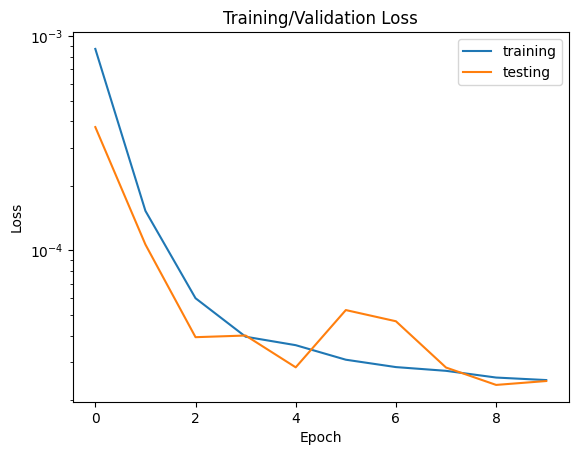

Epoch 11/200, Train Loss: 0.00002379, Test Loss: 0.00002531, Time: 7.99s, LR: 9.98e-04
Epoch 12/200, Train Loss: 0.00002396, Test Loss: 0.00002492, Time: 8.18s, LR: 9.97e-04
Epoch 13/200, Train Loss: 0.00002259, Test Loss: 0.00002022, Time: 8.11s, LR: 9.96e-04
Epoch 14/200, Train Loss: 0.00002187, Test Loss: 0.00001988, Time: 8.15s, LR: 9.95e-04
Epoch 15/200, Train Loss: 0.00002185, Test Loss: 0.00002459, Time: 8.69s, LR: 9.94e-04
Epoch 16/200, Train Loss: 0.00002192, Test Loss: 0.00003466, Time: 8.76s, LR: 9.92e-04
Epoch 17/200, Train Loss: 0.00002253, Test Loss: 0.00003021, Time: 8.80s, LR: 9.91e-04
Epoch 18/200, Train Loss: 0.00002090, Test Loss: 0.00002419, Time: 8.79s, LR: 9.89e-04
Epoch 19/200, Train Loss: 0.00002002, Test Loss: 0.00002173, Time: 8.83s, LR: 9.87e-04
Epoch 20/200, Train Loss: 0.00002115, Test Loss: 0.00003838, Time: 8.84s, LR: 9.85e-04


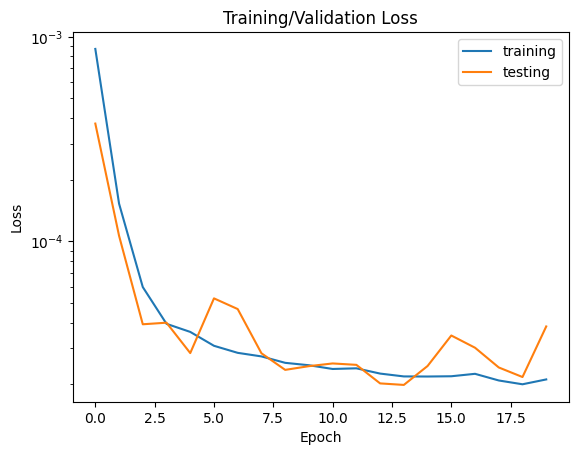

Epoch 21/200, Train Loss: 0.00002124, Test Loss: 0.00001988, Time: 8.84s, LR: 9.83e-04
Epoch 22/200, Train Loss: 0.00002006, Test Loss: 0.00001808, Time: 8.84s, LR: 9.81e-04
Epoch 23/200, Train Loss: 0.00001993, Test Loss: 0.00002588, Time: 8.84s, LR: 9.79e-04
Epoch 24/200, Train Loss: 0.00001940, Test Loss: 0.00001998, Time: 8.88s, LR: 9.77e-04
Epoch 25/200, Train Loss: 0.00001936, Test Loss: 0.00001984, Time: 8.87s, LR: 9.74e-04
Epoch 26/200, Train Loss: 0.00001974, Test Loss: 0.00001941, Time: 8.87s, LR: 9.72e-04
Epoch 27/200, Train Loss: 0.00001977, Test Loss: 0.00002082, Time: 8.88s, LR: 9.69e-04
Epoch 28/200, Train Loss: 0.00002056, Test Loss: 0.00002590, Time: 8.89s, LR: 9.66e-04
Epoch 29/200, Train Loss: 0.00001909, Test Loss: 0.00001859, Time: 8.86s, LR: 9.63e-04
Epoch 30/200, Train Loss: 0.00001952, Test Loss: 0.00002021, Time: 8.88s, LR: 9.60e-04


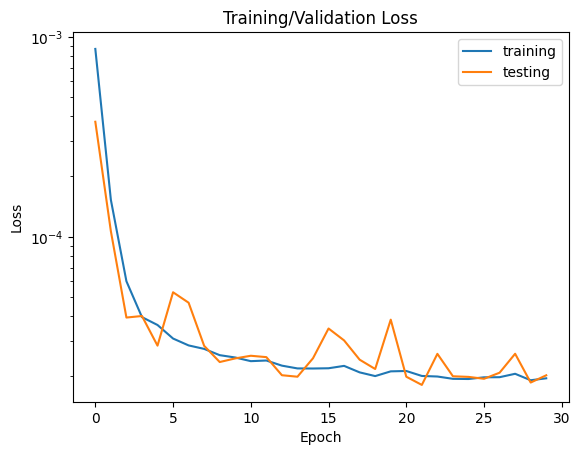

Epoch 31/200, Train Loss: 0.00002104, Test Loss: 0.00006248, Time: 8.90s, LR: 9.57e-04
Epoch 32/200, Train Loss: 0.00002163, Test Loss: 0.00002543, Time: 8.86s, LR: 9.53e-04
Epoch 33/200, Train Loss: 0.00001829, Test Loss: 0.00004373, Time: 8.90s, LR: 9.50e-04
Epoch 34/200, Train Loss: 0.00001785, Test Loss: 0.00002708, Time: 8.85s, LR: 9.46e-04
Epoch 35/200, Train Loss: 0.00001830, Test Loss: 0.00003383, Time: 8.91s, LR: 9.43e-04
Epoch 36/200, Train Loss: 0.00001821, Test Loss: 0.00002231, Time: 8.89s, LR: 9.39e-04
Epoch 37/200, Train Loss: 0.00001781, Test Loss: 0.00001880, Time: 8.90s, LR: 9.35e-04
Epoch 38/200, Train Loss: 0.00001771, Test Loss: 0.00002375, Time: 8.89s, LR: 9.31e-04
Epoch 39/200, Train Loss: 0.00001809, Test Loss: 0.00004193, Time: 8.87s, LR: 9.27e-04
Epoch 40/200, Train Loss: 0.00001831, Test Loss: 0.00002004, Time: 8.86s, LR: 9.23e-04


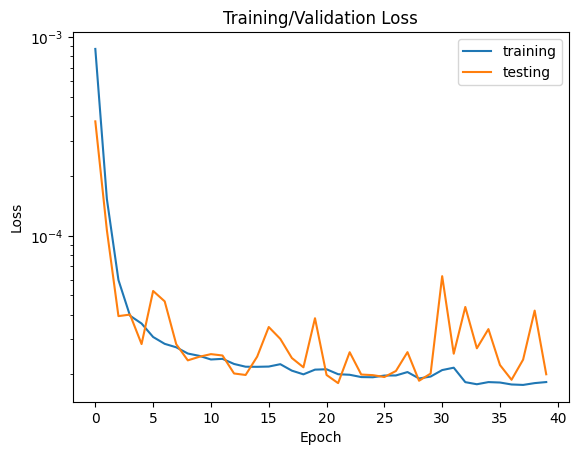

Epoch 41/200, Train Loss: 0.00001774, Test Loss: 0.00002503, Time: 8.88s, LR: 9.18e-04
Epoch 42/200, Train Loss: 0.00001811, Test Loss: 0.00002667, Time: 8.86s, LR: 9.14e-04
Epoch 43/200, Train Loss: 0.00001878, Test Loss: 0.00002071, Time: 8.86s, LR: 9.09e-04
Epoch 44/200, Train Loss: 0.00001758, Test Loss: 0.00002973, Time: 8.89s, LR: 9.05e-04
Epoch 45/200, Train Loss: 0.00001736, Test Loss: 0.00002421, Time: 8.89s, LR: 9.00e-04
Epoch 46/200, Train Loss: 0.00001746, Test Loss: 0.00001816, Time: 8.87s, LR: 8.95e-04
Epoch 47/200, Train Loss: 0.00001775, Test Loss: 0.00003718, Time: 8.90s, LR: 8.90e-04
Epoch 48/200, Train Loss: 0.00001768, Test Loss: 0.00003028, Time: 8.87s, LR: 8.85e-04
Epoch 49/200, Train Loss: 0.00001762, Test Loss: 0.00002283, Time: 8.88s, LR: 8.80e-04
Epoch 50/200, Train Loss: 0.00001729, Test Loss: 0.00001929, Time: 8.89s, LR: 8.74e-04


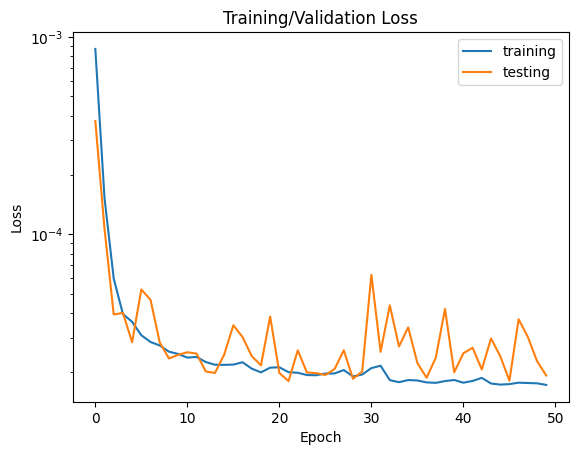

Epoch 51/200, Train Loss: 0.00001742, Test Loss: 0.00001866, Time: 8.86s, LR: 8.69e-04
Epoch 52/200, Train Loss: 0.00001702, Test Loss: 0.00002156, Time: 8.90s, LR: 8.63e-04
Early stopping at epoch 52. Best val loss: 0.02101847


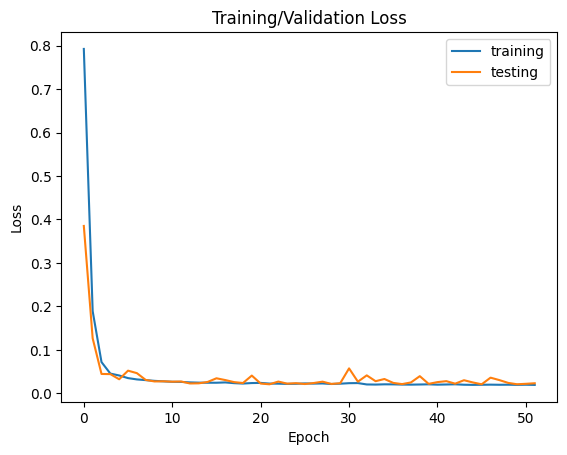

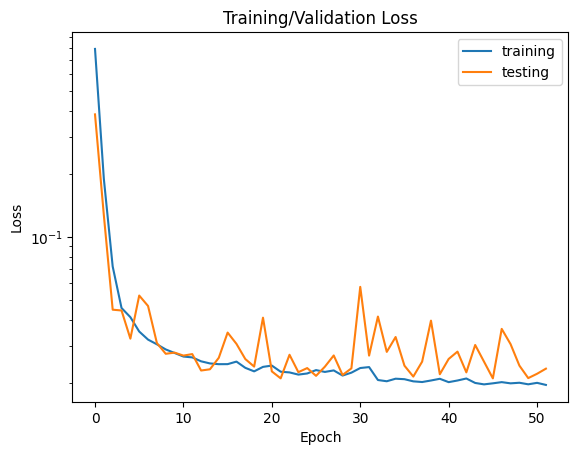

In [41]:
import os
from datetime import date

# === Base Model ===
baseline_tags = "BASELINE_NO_PITA"
# baseline_epochs = 200

model_base = U_net(input_channels=2, output_channels=2, kernel_size=5, dropout_rate=0.2,).to(device)

print(f"Baseline params: {count_params(model_base)}")
b_train_losses, b_test_losses, b_best = train_recursive(model_base
                                                        , train_loader
                                                        , test_loader
                                                        , num_steps=T_out
                                                        , num_epochs=epochs
                                                        , plot_interval=10
                                                        , teacher_forcing=False
                                                        , clip_grad=0.5
                                                        , early_stopping_patience=30
                                                        , u_x_std=u_x_std
                                                        , u_y_std=u_y_std
                                                        , use_pita=False)

plt.plot(b_train_losses, label="training")
plt.plot(b_test_losses, label="testing")
plt.yscale('log') # Added log scale to y-axis
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training/Validation Loss')
plt.legend()
plt.show()

PITA params: 58109814
Epoch 1/200, Train Loss: 0.00008040, Test Loss: 0.00029050, Time: 8.94s, LR: 4.00e-04
Epoch 2/200, Train Loss: 0.00001534, Test Loss: 0.00014510, Time: 8.92s, LR: 6.00e-04
Epoch 3/200, Train Loss: 0.00000626, Test Loss: 0.00008009, Time: 8.97s, LR: 8.00e-04
Epoch 4/200, Train Loss: 0.00000404, Test Loss: 0.00007126, Time: 9.01s, LR: 1.00e-03
Epoch 5/200, Train Loss: 0.00000416, Test Loss: 0.00003644, Time: 8.97s, LR: 1.00e-03
Epoch 6/200, Train Loss: 0.00000321, Test Loss: 0.00005675, Time: 8.98s, LR: 1.00e-03
Epoch 7/200, Train Loss: 0.00000286, Test Loss: 0.00004425, Time: 9.03s, LR: 1.00e-03
Epoch 8/200, Train Loss: 0.00000277, Test Loss: 0.00006316, Time: 9.04s, LR: 9.99e-04
Epoch 9/200, Train Loss: 0.00000299, Test Loss: 0.00007507, Time: 9.01s, LR: 9.99e-04
Epoch 10/200, Train Loss: 0.00000269, Test Loss: 0.00004947, Time: 9.04s, LR: 9.98e-04


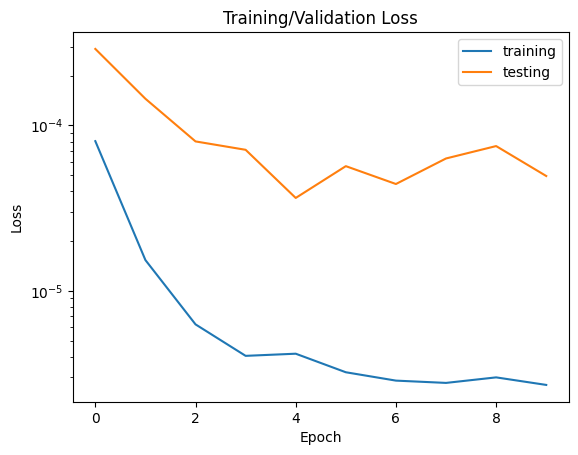

Epoch 11/200, Train Loss: 0.00000250, Test Loss: 0.00002760, Time: 9.02s, LR: 9.98e-04
Epoch 12/200, Train Loss: 0.00000243, Test Loss: 0.00002196, Time: 9.00s, LR: 9.97e-04
Epoch 13/200, Train Loss: 0.00000255, Test Loss: 0.00005325, Time: 9.02s, LR: 9.96e-04
Epoch 14/200, Train Loss: 0.00000249, Test Loss: 0.00002405, Time: 9.02s, LR: 9.95e-04
Epoch 15/200, Train Loss: 0.00000225, Test Loss: 0.00002595, Time: 9.04s, LR: 9.94e-04
Epoch 16/200, Train Loss: 0.00000220, Test Loss: 0.00002379, Time: 9.01s, LR: 9.92e-04
Epoch 17/200, Train Loss: 0.00000220, Test Loss: 0.00002771, Time: 9.02s, LR: 9.91e-04
Epoch 18/200, Train Loss: 0.00000231, Test Loss: 0.00002583, Time: 9.00s, LR: 9.89e-04
Epoch 19/200, Train Loss: 0.00000204, Test Loss: 0.00004387, Time: 8.99s, LR: 9.87e-04
Epoch 20/200, Train Loss: 0.00000230, Test Loss: 0.00004377, Time: 9.05s, LR: 9.85e-04


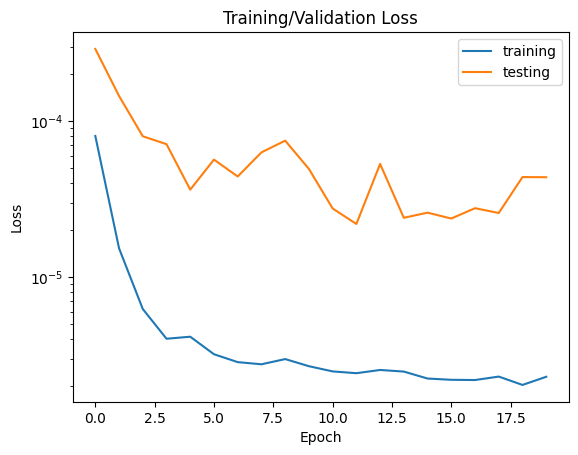

Epoch 21/200, Train Loss: 0.00000235, Test Loss: 0.00003597, Time: 9.03s, LR: 9.83e-04
Epoch 22/200, Train Loss: 0.00000216, Test Loss: 0.00002494, Time: 9.04s, LR: 9.81e-04
Epoch 23/200, Train Loss: 0.00000200, Test Loss: 0.00002783, Time: 9.00s, LR: 9.79e-04
Epoch 24/200, Train Loss: 0.00000200, Test Loss: 0.00002029, Time: 9.03s, LR: 9.77e-04
Epoch 25/200, Train Loss: 0.00000189, Test Loss: 0.00002087, Time: 9.00s, LR: 9.74e-04
Epoch 26/200, Train Loss: 0.00000211, Test Loss: 0.00002842, Time: 9.04s, LR: 9.72e-04
Epoch 27/200, Train Loss: 0.00000194, Test Loss: 0.00002235, Time: 9.05s, LR: 9.69e-04
Epoch 28/200, Train Loss: 0.00000185, Test Loss: 0.00001874, Time: 9.02s, LR: 9.66e-04
Epoch 29/200, Train Loss: 0.00000187, Test Loss: 0.00003226, Time: 9.05s, LR: 9.63e-04
Epoch 30/200, Train Loss: 0.00000194, Test Loss: 0.00004376, Time: 9.01s, LR: 9.60e-04


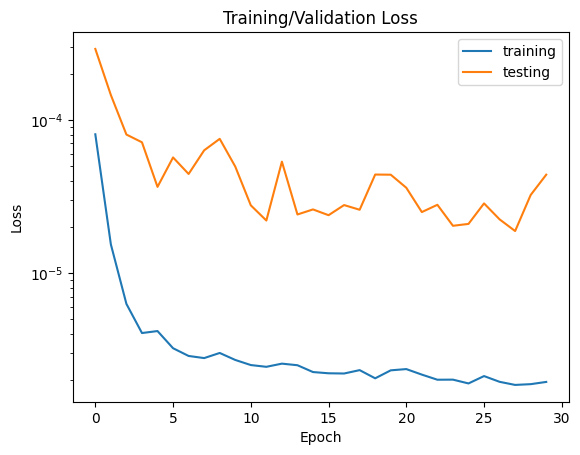

Epoch 31/200, Train Loss: 0.00000189, Test Loss: 0.00002304, Time: 9.02s, LR: 9.57e-04
Epoch 32/200, Train Loss: 0.00000185, Test Loss: 0.00001967, Time: 9.03s, LR: 9.53e-04
Epoch 33/200, Train Loss: 0.00000178, Test Loss: 0.00002044, Time: 9.05s, LR: 9.50e-04
Epoch 34/200, Train Loss: 0.00000177, Test Loss: 0.00002432, Time: 9.04s, LR: 9.46e-04
Epoch 35/200, Train Loss: 0.00000190, Test Loss: 0.00002153, Time: 9.06s, LR: 9.43e-04
Epoch 36/200, Train Loss: 0.00000198, Test Loss: 0.00002929, Time: 9.03s, LR: 9.39e-04
Epoch 37/200, Train Loss: 0.00000187, Test Loss: 0.00001821, Time: 9.05s, LR: 9.35e-04
Epoch 38/200, Train Loss: 0.00000181, Test Loss: 0.00001936, Time: 9.08s, LR: 9.31e-04
Epoch 39/200, Train Loss: 0.00000216, Test Loss: 0.00002212, Time: 9.01s, LR: 9.27e-04
Epoch 40/200, Train Loss: 0.00000178, Test Loss: 0.00001777, Time: 9.07s, LR: 9.23e-04


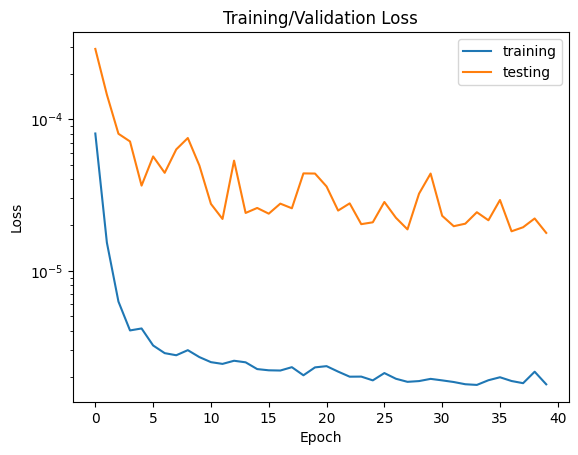

Epoch 41/200, Train Loss: 0.00000174, Test Loss: 0.00002300, Time: 9.07s, LR: 9.18e-04
Epoch 42/200, Train Loss: 0.00000171, Test Loss: 0.00001747, Time: 8.99s, LR: 9.14e-04
Epoch 43/200, Train Loss: 0.00000178, Test Loss: 0.00001925, Time: 8.91s, LR: 9.09e-04
Epoch 44/200, Train Loss: 0.00000170, Test Loss: 0.00002035, Time: 8.98s, LR: 9.05e-04
Epoch 45/200, Train Loss: 0.00000170, Test Loss: 0.00001846, Time: 9.01s, LR: 9.00e-04
Epoch 46/200, Train Loss: 0.00000170, Test Loss: 0.00002194, Time: 8.96s, LR: 8.95e-04
Epoch 47/200, Train Loss: 0.00000176, Test Loss: 0.00002221, Time: 9.03s, LR: 8.90e-04
Epoch 48/200, Train Loss: 0.00000174, Test Loss: 0.00002340, Time: 9.00s, LR: 8.85e-04
Epoch 49/200, Train Loss: 0.00000186, Test Loss: 0.00002233, Time: 8.98s, LR: 8.80e-04
Epoch 50/200, Train Loss: 0.00000171, Test Loss: 0.00001918, Time: 8.92s, LR: 8.74e-04


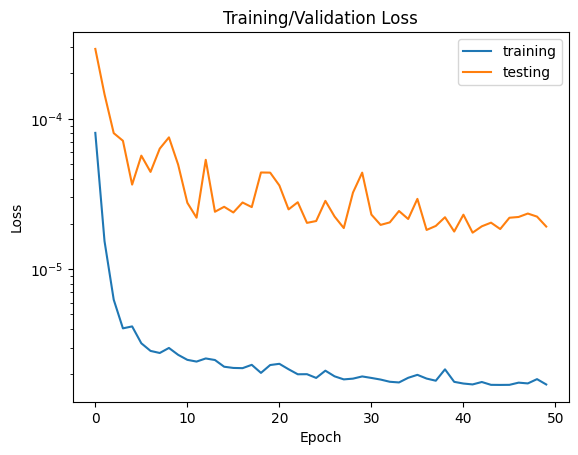

Epoch 51/200, Train Loss: 0.00000170, Test Loss: 0.00001827, Time: 8.98s, LR: 8.69e-04
Epoch 52/200, Train Loss: 0.00000172, Test Loss: 0.00003114, Time: 8.96s, LR: 8.63e-04
Epoch 53/200, Train Loss: 0.00000177, Test Loss: 0.00002279, Time: 8.98s, LR: 8.58e-04
Epoch 54/200, Train Loss: 0.00000172, Test Loss: 0.00002303, Time: 8.96s, LR: 8.52e-04
Epoch 55/200, Train Loss: 0.00000169, Test Loss: 0.00001873, Time: 8.99s, LR: 8.46e-04
Epoch 56/200, Train Loss: 0.00000175, Test Loss: 0.00003179, Time: 8.94s, LR: 8.41e-04
Epoch 57/200, Train Loss: 0.00000181, Test Loss: 0.00001940, Time: 8.95s, LR: 8.35e-04
Epoch 58/200, Train Loss: 0.00000182, Test Loss: 0.00001949, Time: 8.99s, LR: 8.29e-04
Epoch 59/200, Train Loss: 0.00000181, Test Loss: 0.00002136, Time: 8.99s, LR: 8.22e-04
Epoch 60/200, Train Loss: 0.00000169, Test Loss: 0.00001978, Time: 9.02s, LR: 8.16e-04


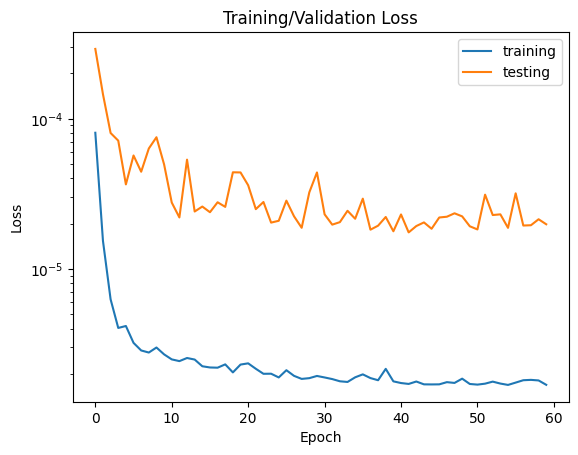

Epoch 61/200, Train Loss: 0.00000182, Test Loss: 0.00002156, Time: 9.03s, LR: 8.10e-04
Epoch 62/200, Train Loss: 0.00000172, Test Loss: 0.00001884, Time: 8.99s, LR: 8.04e-04
Epoch 63/200, Train Loss: 0.00000176, Test Loss: 0.00001738, Time: 8.69s, LR: 7.97e-04
Epoch 64/200, Train Loss: 0.00000168, Test Loss: 0.00002274, Time: 8.55s, LR: 7.91e-04
Epoch 65/200, Train Loss: 0.00000168, Test Loss: 0.00001802, Time: 8.98s, LR: 7.84e-04
Epoch 66/200, Train Loss: 0.00000168, Test Loss: 0.00001756, Time: 9.02s, LR: 7.77e-04
Epoch 67/200, Train Loss: 0.00000164, Test Loss: 0.00002529, Time: 8.97s, LR: 7.71e-04
Epoch 68/200, Train Loss: 0.00000166, Test Loss: 0.00001975, Time: 8.30s, LR: 7.64e-04
Epoch 69/200, Train Loss: 0.00000161, Test Loss: 0.00001964, Time: 8.54s, LR: 7.57e-04
Epoch 70/200, Train Loss: 0.00000169, Test Loss: 0.00002652, Time: 8.73s, LR: 7.50e-04


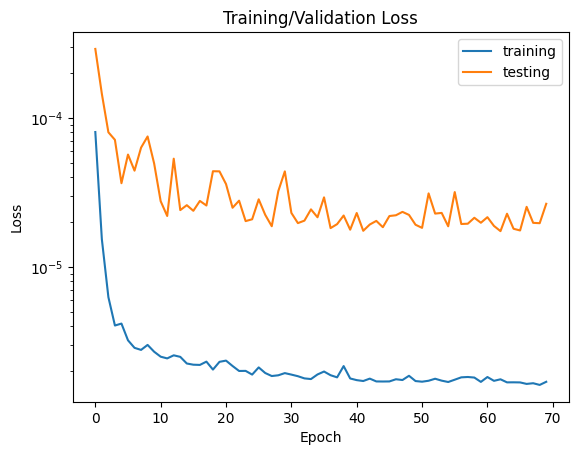

Epoch 71/200, Train Loss: 0.00000164, Test Loss: 0.00002341, Time: 8.38s, LR: 7.43e-04
Epoch 72/200, Train Loss: 0.00000167, Test Loss: 0.00001867, Time: 8.58s, LR: 7.36e-04
Epoch 73/200, Train Loss: 0.00000165, Test Loss: 0.00002454, Time: 8.63s, LR: 7.29e-04
Epoch 74/200, Train Loss: 0.00000167, Test Loss: 0.00002299, Time: 9.05s, LR: 7.22e-04
Epoch 75/200, Train Loss: 0.00000160, Test Loss: 0.00001813, Time: 9.01s, LR: 7.14e-04
Epoch 76/200, Train Loss: 0.00000160, Test Loss: 0.00001777, Time: 8.95s, LR: 7.07e-04
Epoch 77/200, Train Loss: 0.00000159, Test Loss: 0.00001789, Time: 8.65s, LR: 7.00e-04
Epoch 78/200, Train Loss: 0.00000162, Test Loss: 0.00002036, Time: 8.74s, LR: 6.92e-04
Epoch 79/200, Train Loss: 0.00000162, Test Loss: 0.00001775, Time: 9.01s, LR: 6.85e-04
Epoch 80/200, Train Loss: 0.00000159, Test Loss: 0.00001808, Time: 8.87s, LR: 6.77e-04


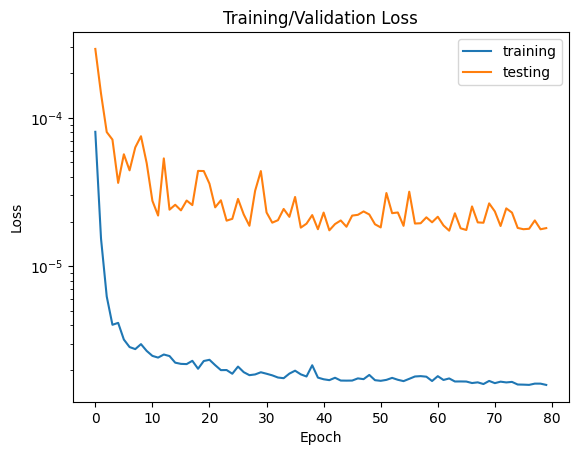

Epoch 81/200, Train Loss: 0.00000171, Test Loss: 0.00002035, Time: 9.11s, LR: 6.70e-04
Epoch 82/200, Train Loss: 0.00000161, Test Loss: 0.00002257, Time: 9.04s, LR: 6.62e-04
Epoch 83/200, Train Loss: 0.00000165, Test Loss: 0.00002079, Time: 8.76s, LR: 6.55e-04
Epoch 84/200, Train Loss: 0.00000167, Test Loss: 0.00001798, Time: 8.96s, LR: 6.47e-04
Epoch 85/200, Train Loss: 0.00000162, Test Loss: 0.00002305, Time: 8.66s, LR: 6.39e-04
Epoch 86/200, Train Loss: 0.00000159, Test Loss: 0.00001836, Time: 9.01s, LR: 6.31e-04
Epoch 87/200, Train Loss: 0.00000163, Test Loss: 0.00002054, Time: 8.83s, LR: 6.24e-04
Epoch 88/200, Train Loss: 0.00000159, Test Loss: 0.00001868, Time: 9.07s, LR: 6.16e-04
Epoch 89/200, Train Loss: 0.00000158, Test Loss: 0.00002233, Time: 9.05s, LR: 6.08e-04
Epoch 90/200, Train Loss: 0.00000160, Test Loss: 0.00001969, Time: 9.06s, LR: 6.00e-04


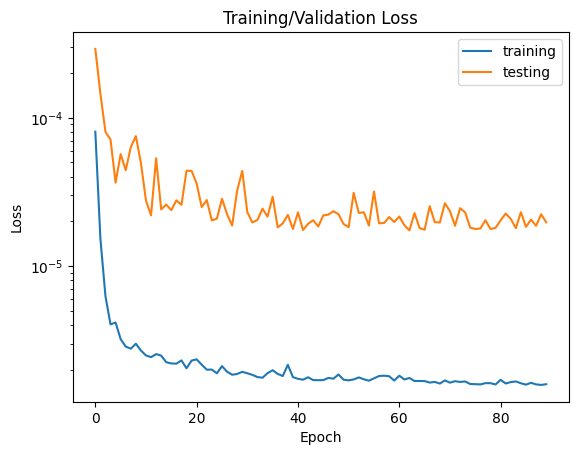

Epoch 91/200, Train Loss: 0.00000162, Test Loss: 0.00001776, Time: 9.04s, LR: 5.92e-04
Epoch 92/200, Train Loss: 0.00000160, Test Loss: 0.00001754, Time: 9.04s, LR: 5.84e-04
Epoch 93/200, Train Loss: 0.00000160, Test Loss: 0.00002139, Time: 9.09s, LR: 5.76e-04
Early stopping at epoch 93. Best val loss: 0.01985190


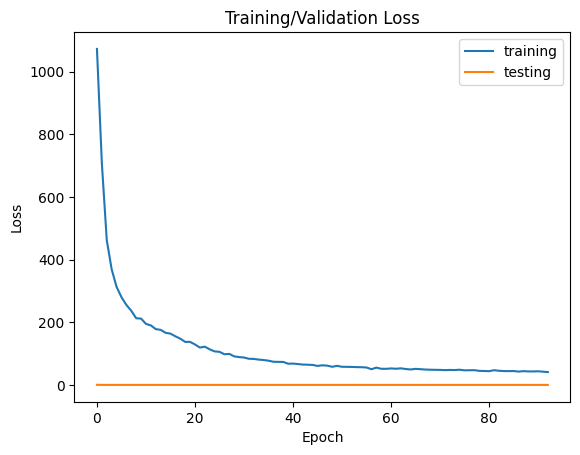

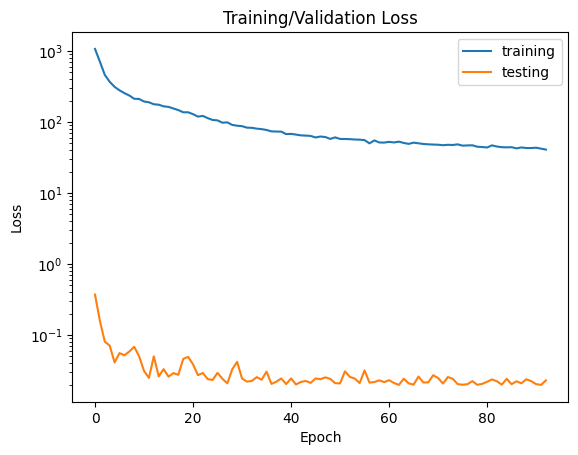

In [42]:
# === With Pita ===
pita_tags = "BASELINE_WITH_PITA"

model_pita = U_net(
    input_channels=2, output_channels=2,
    kernel_size=5, dropout_rate=0.2,
).to(device)

print(f"PITA params: {count_params(model_pita)}")
p_train_losses, p_test_losses, p_best = train_recursive(
    model_pita,
    train_loader,
    test_loader,
    num_steps=T_out,
    num_epochs=epochs,
    plot_interval=10,
    teacher_forcing=False,
    clip_grad=0.5,
    early_stopping_patience=30,
    u_x_std=u_x_std,
    u_y_std=u_y_std,
    use_pita=True,
    PITA_threshold=0.05,
    PITA_downsample=4,
    PITA_alpha_l0=1e-4,
)

plt.plot(p_train_losses, label="training")
plt.plot(p_test_losses, label="testing")
plt.yscale('log') # Added log scale to y-axis
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training/Validation Loss')
plt.legend()
plt.show()


## Evaluating and saving


Defining a function to run the fully trained model on our test data.

In [43]:
def test_recursive(model, dataloader, num_steps=10):
    # We want to put the model in evaluate mode now to get rid of any
    model.eval()
    u_actual = []
    u_pred = []
    with torch.no_grad():
      for batch in dataloader:
          # Expected batch keys:
          # 'u0': initial velocity field, shape (batch_size, 2, 89, 144)
          # 'targets': ground truth evolution for next num_steps timesteps,
          #            shape (batch_size, num_steps, 2, 89, 144)
          u0 = batch['u0'].to(device)
          targets = batch['targets'].to(device)
          u_actual.append(torch.cat((u0.unsqueeze(1), targets), dim=1))

          predictions = recursive_prediction(model, u0, num_steps=num_steps)
          u_pred.append(torch.stack(predictions, dim=1))
          # predictions is a list of length (num_steps+1): first element is u0, then each future timestep
    plot_velocity_field(predictions)
    u_actual = torch.cat(u_actual, dim=0).permute(2, 0, 3, 4, 1)
    u_pred = torch.cat(u_pred, dim=0).permute(2, 0, 3, 4, 1)
    return u_actual, u_pred



Run this and save it

In [45]:
from datetime import date

current_date = date.today()
formatted_date = current_date.strftime("%Y%m%d") # YYYY-MM-DD format


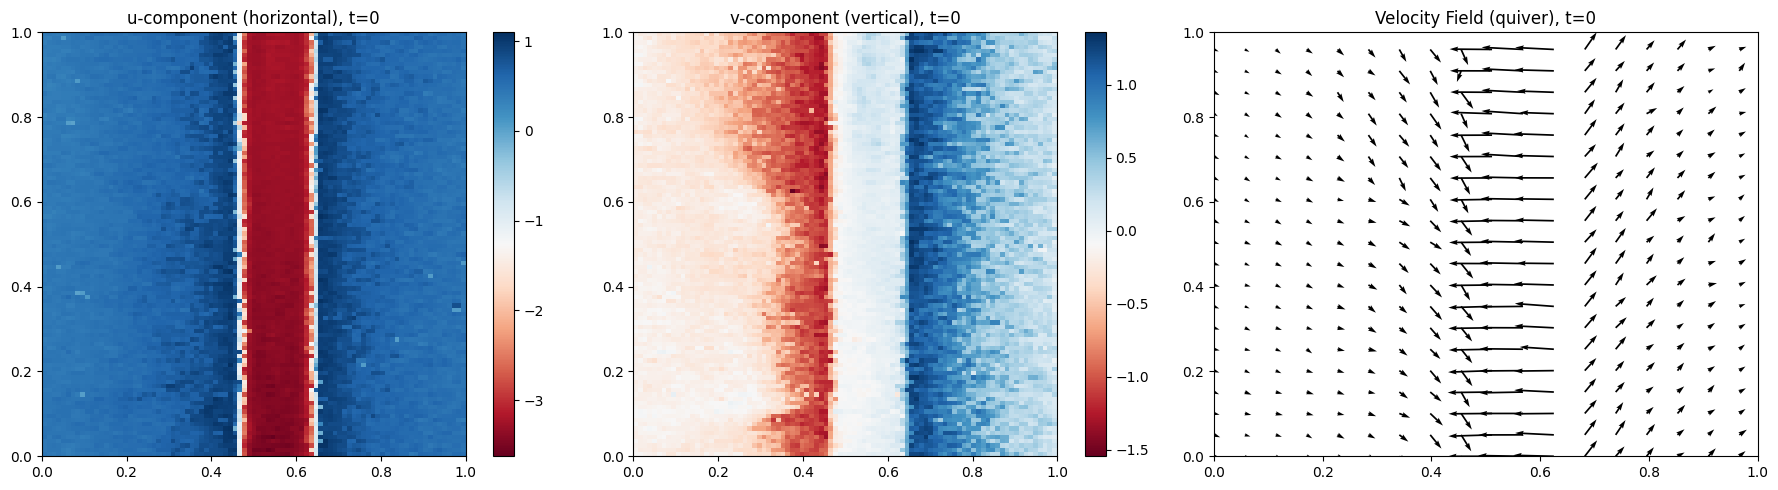

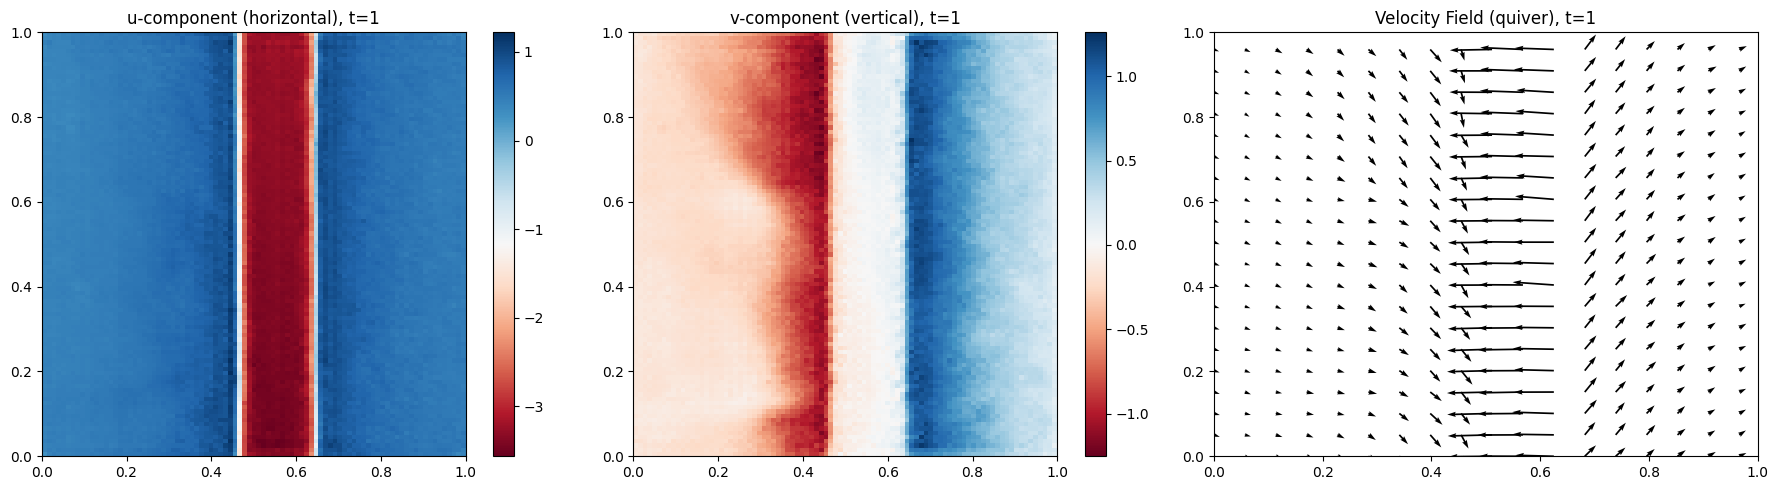

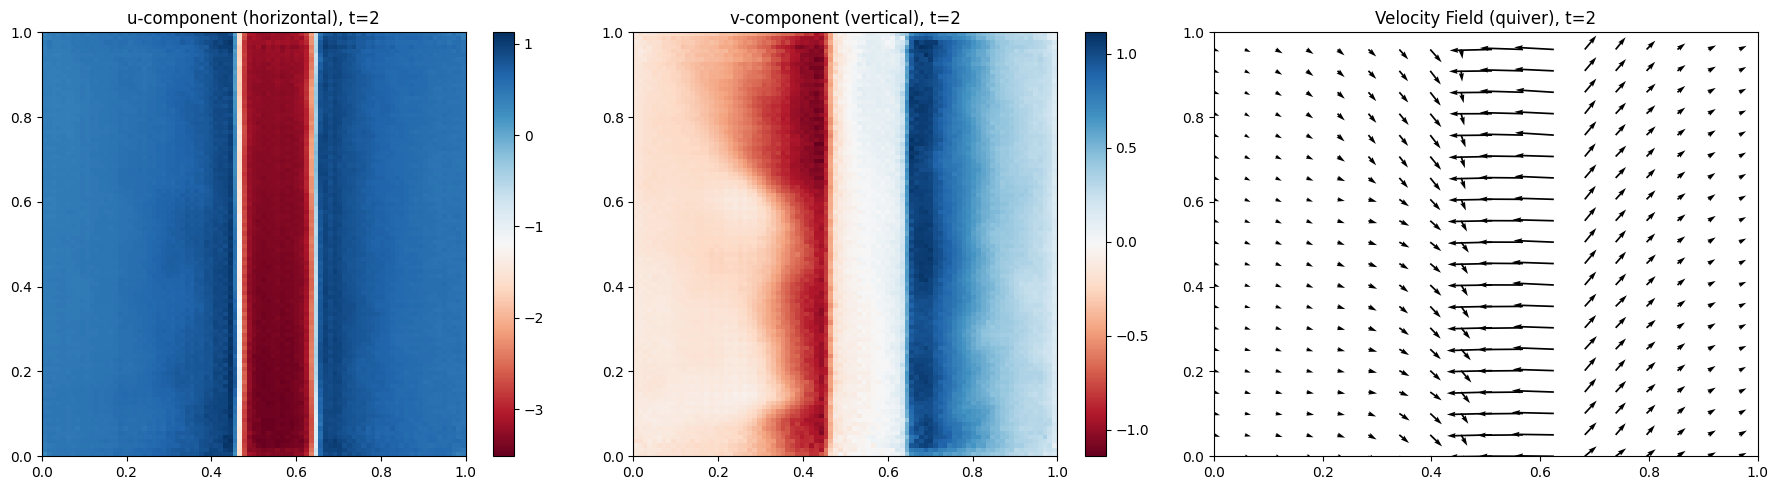

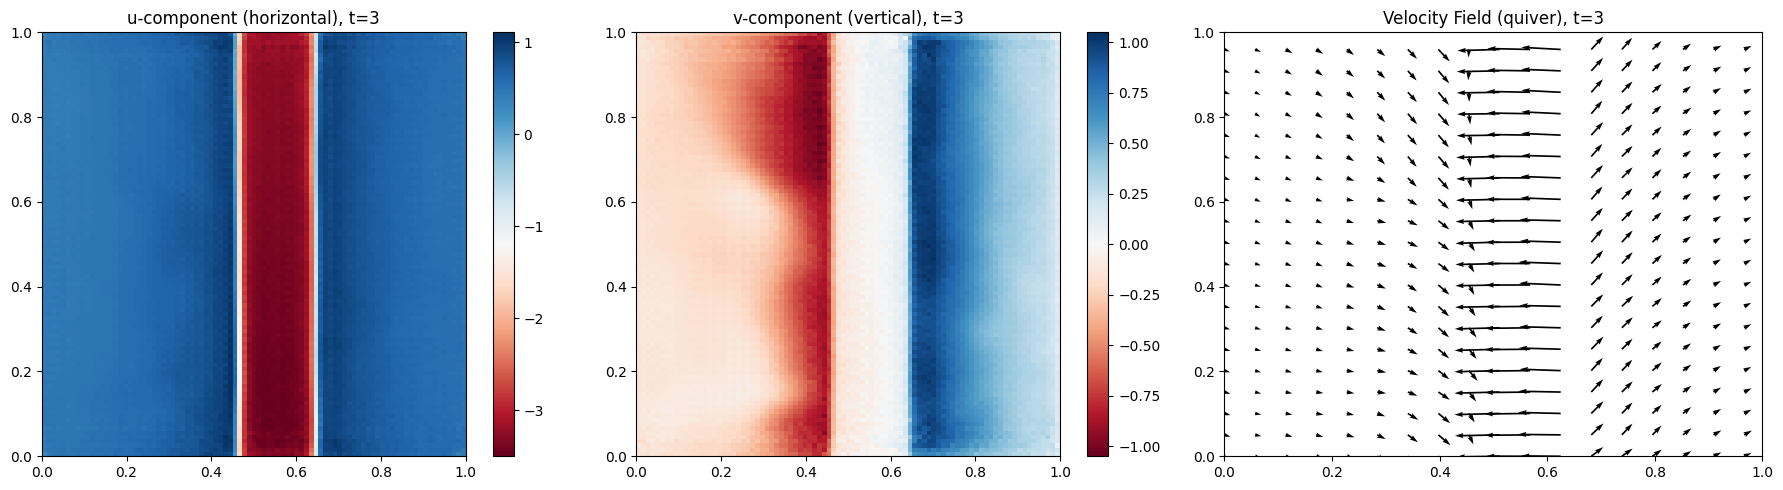

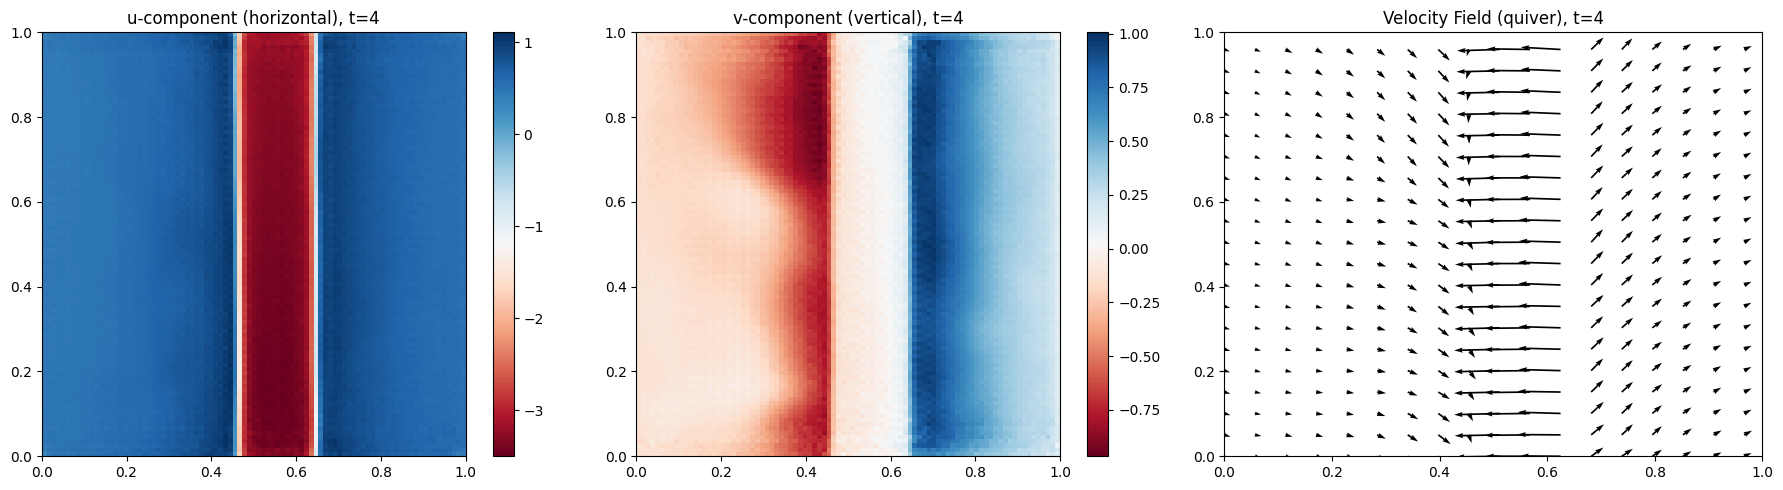

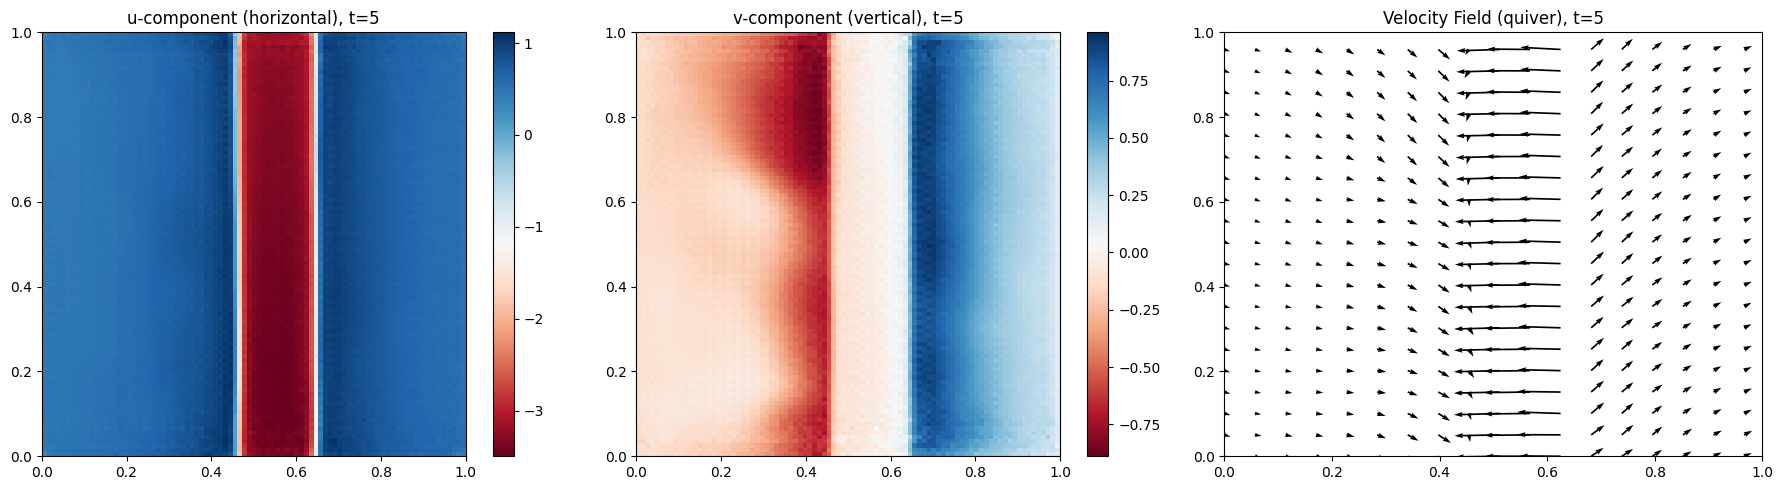

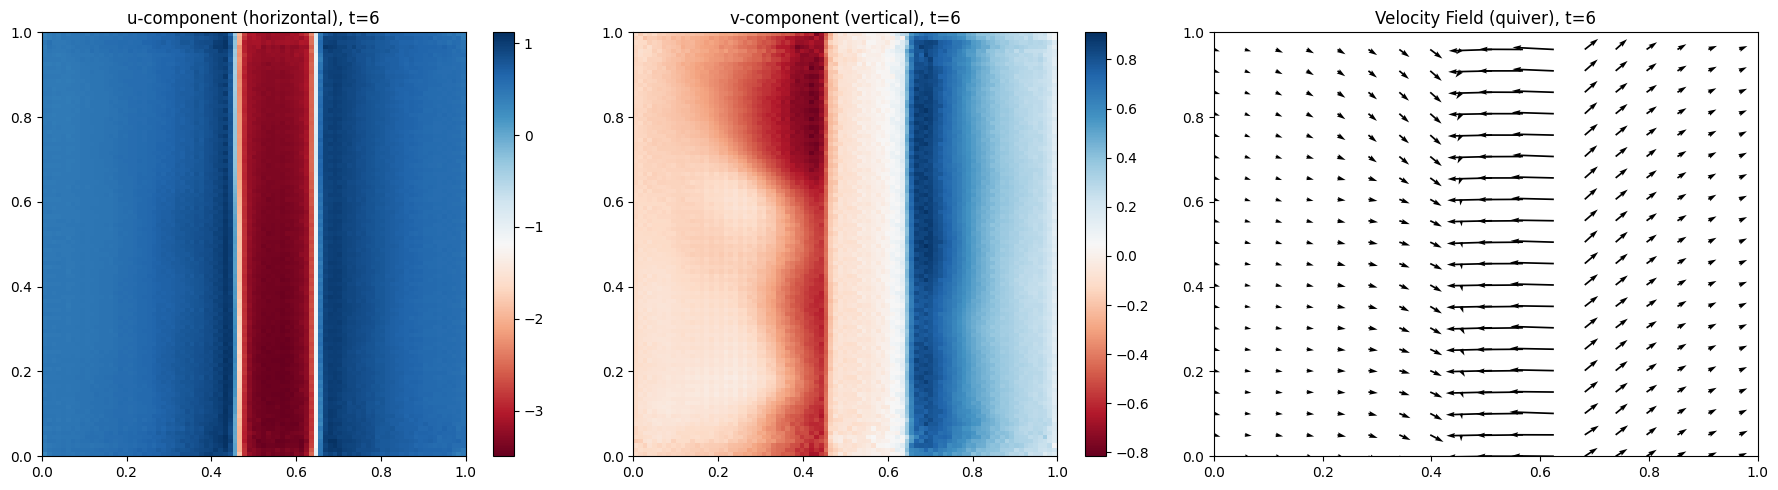

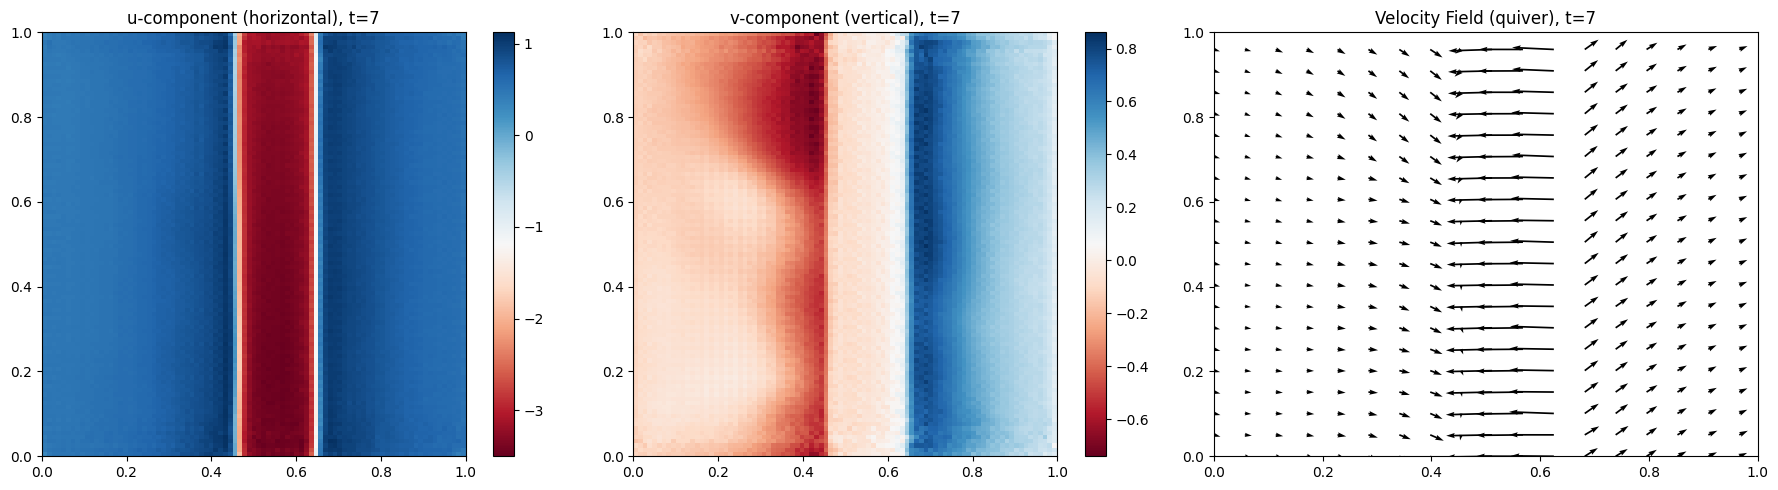

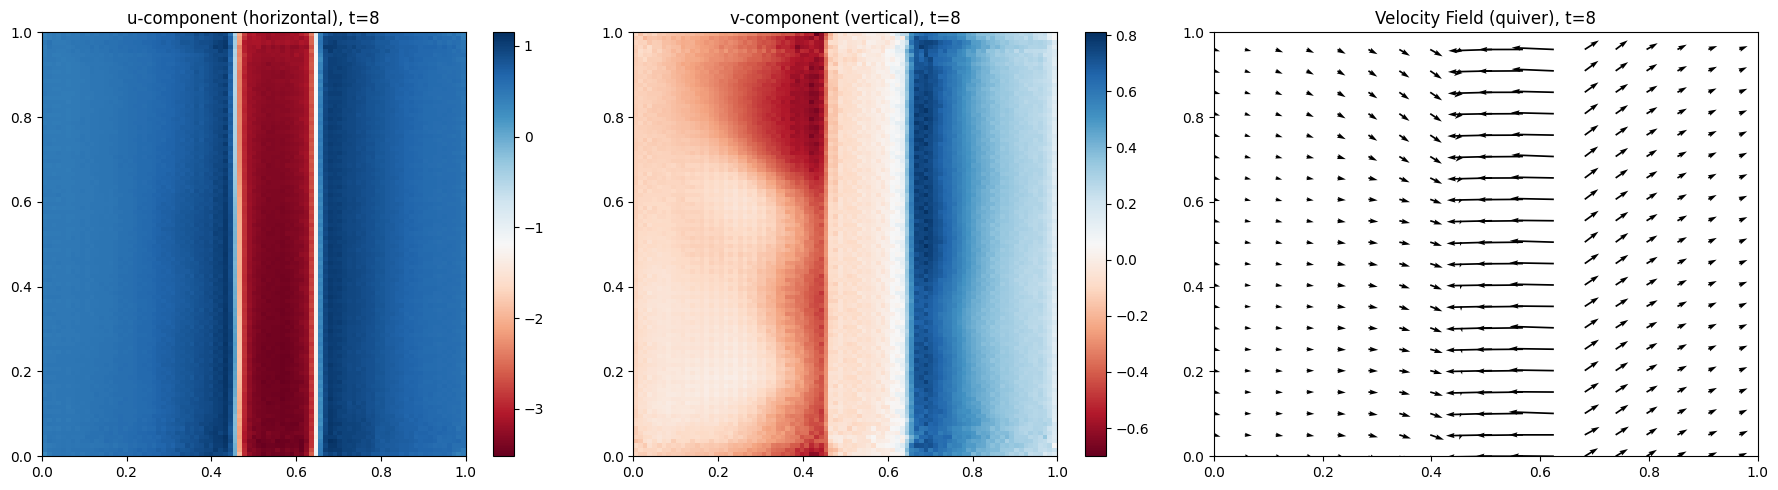

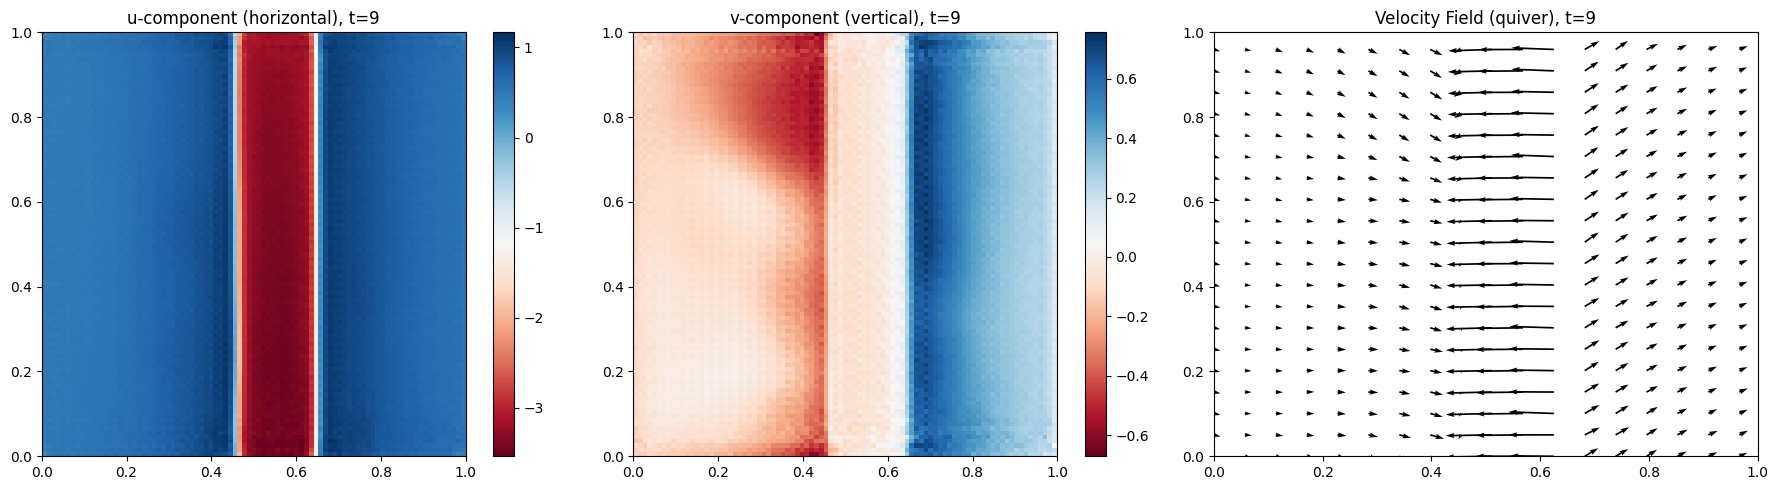

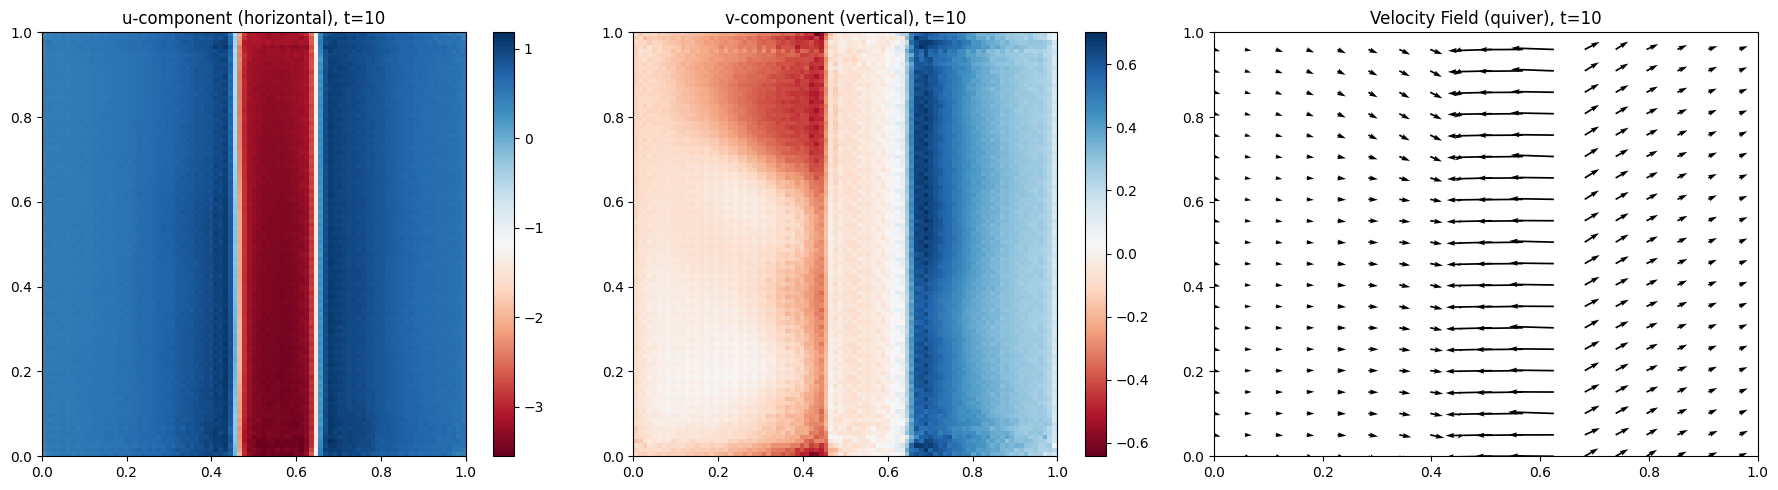

Baseline outputs saved to ./UNet Output/20260619_UNet_200_epoch_32_5Hz_200fpsBASELINE_NO_PITA.h5


In [46]:
# save baseline
b_u_actual, b_u_pred = test_recursive(model_base, test_loader)

output_dir = './UNet Output/'
os.makedirs(output_dir, exist_ok=True)
b_formatted_date = date.today().strftime("%y%m%d")
b_fname = f'{output_dir}{formatted_date}_UNet_{epochs}_epoch_{batch_size}_{speed}{baseline_tags}.h5'

with h5py.File(b_fname, 'w') as f:
    f.create_dataset('u_actual',     data=b_u_actual.cpu().numpy())
    f.create_dataset('u_pred',       data=b_u_pred.cpu().numpy())
    f.create_dataset('train_losses', data=np.array(b_train_losses))
    f.create_dataset('test_losses',  data=np.array(b_test_losses))
    f.create_dataset('u_x_mean',     data=u_x_mean)
    f.create_dataset('u_x_std',      data=u_x_std)
    f.create_dataset('u_y_mean',     data=u_y_mean)
    f.create_dataset('u_y_std',      data=u_y_std)

print(f"Baseline outputs saved to {b_fname}")
torch.save(model_base, f'{output_dir}{b_formatted_date}_UNet_{epochs}_epoch_{batch_size}_{speed}_{baseline_tags}.pt')

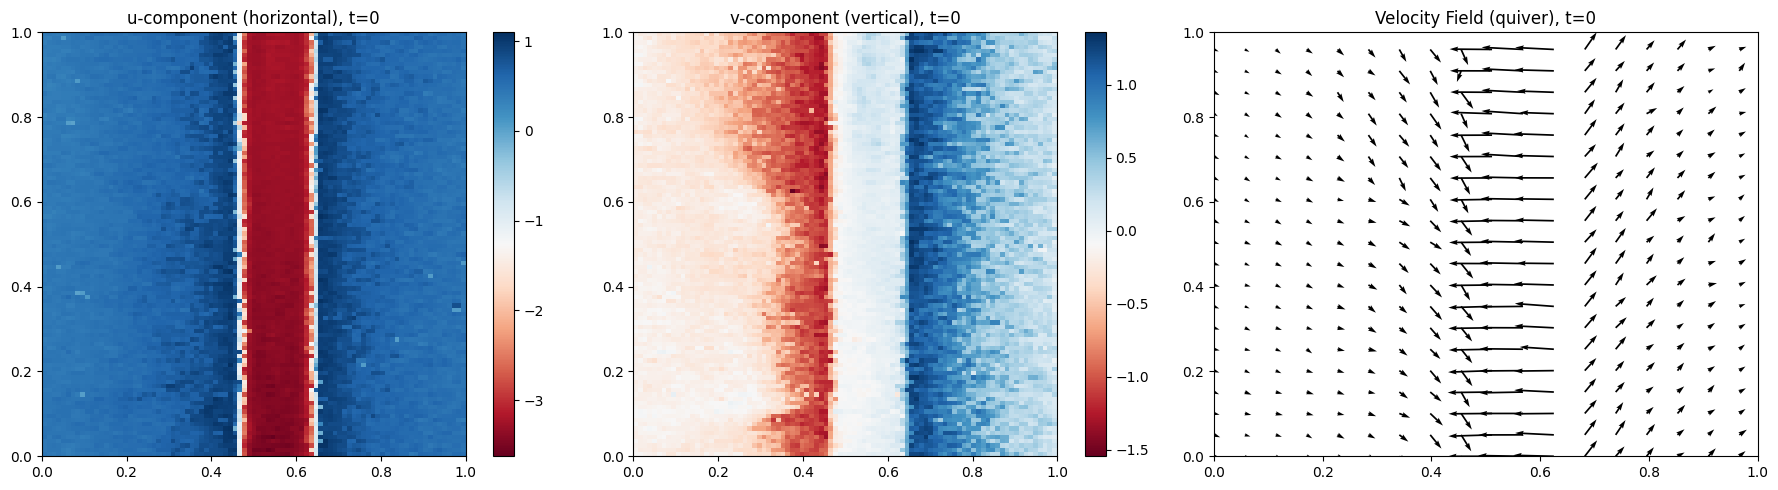

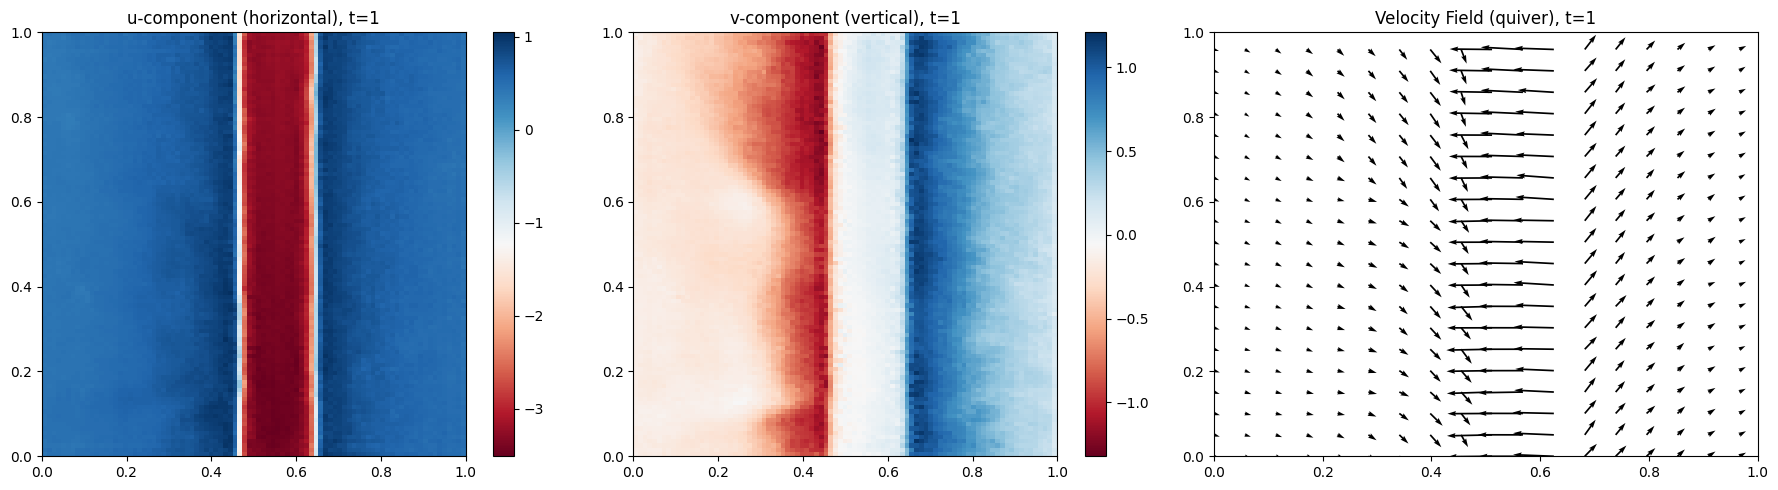

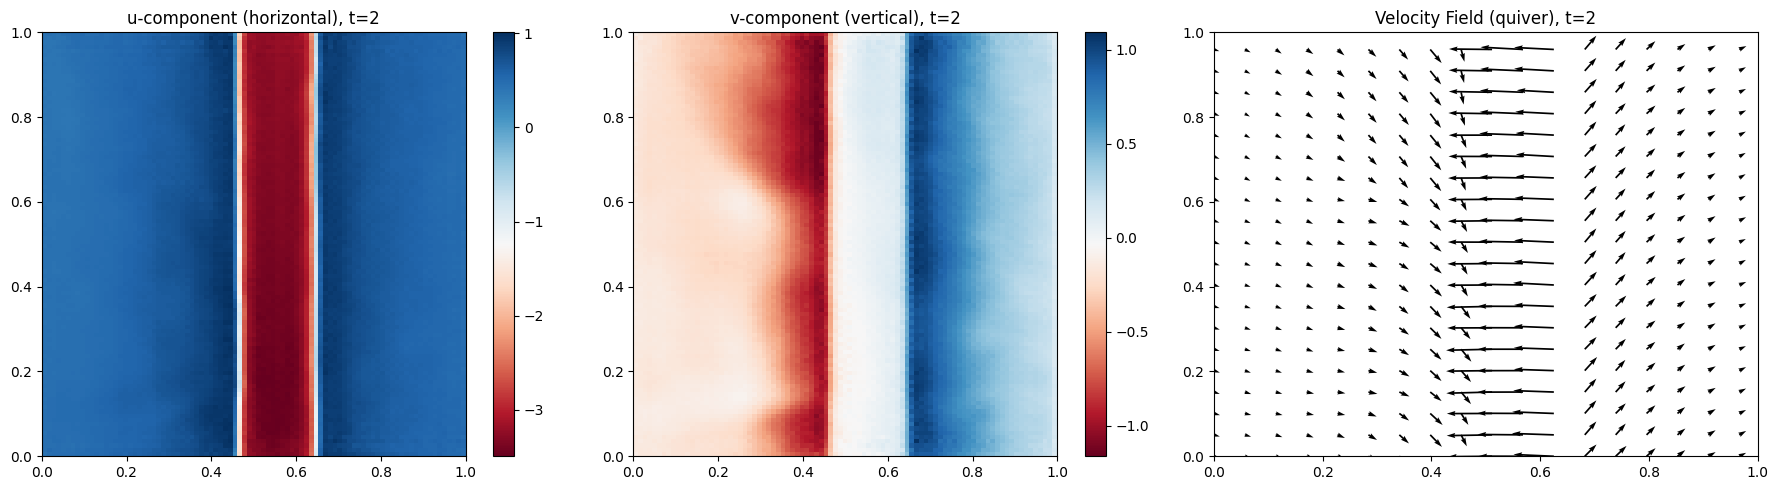

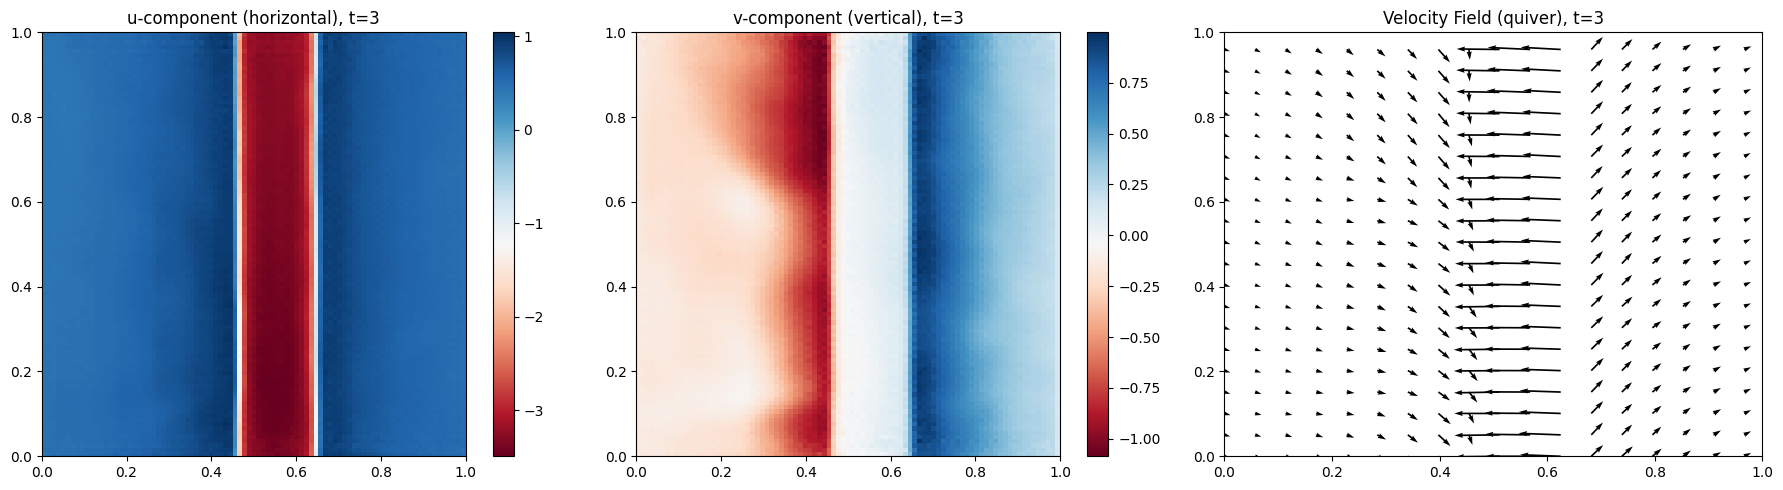

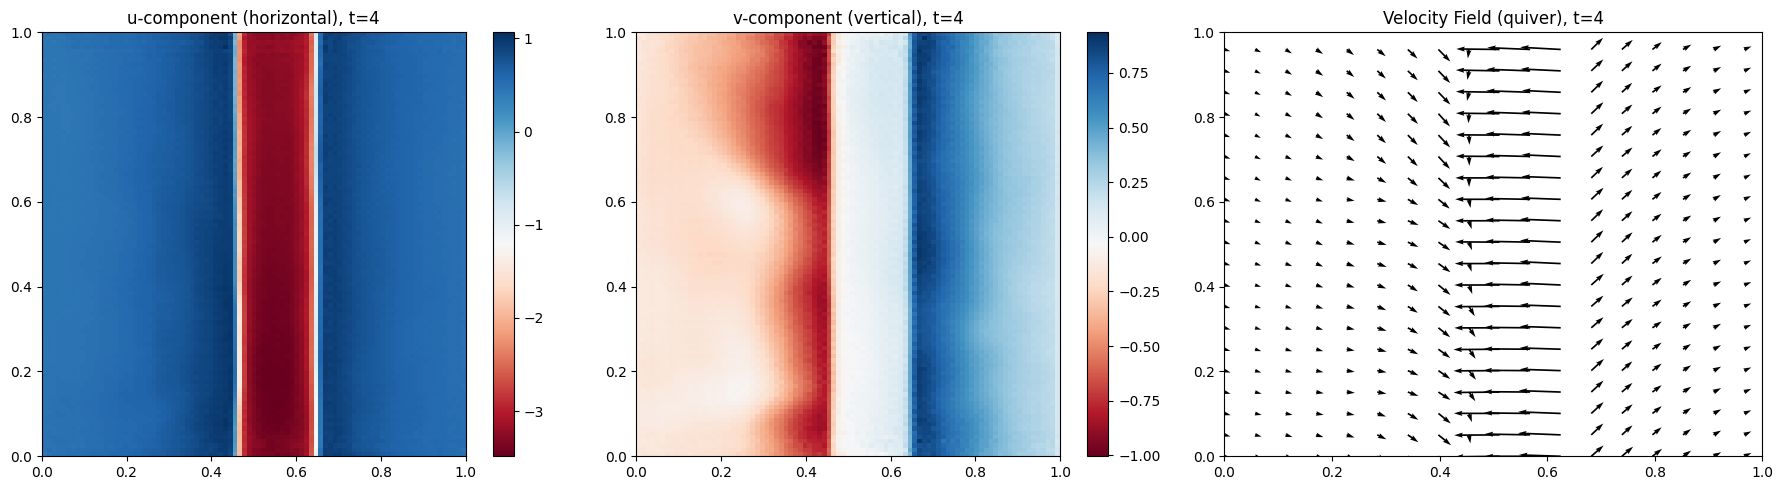

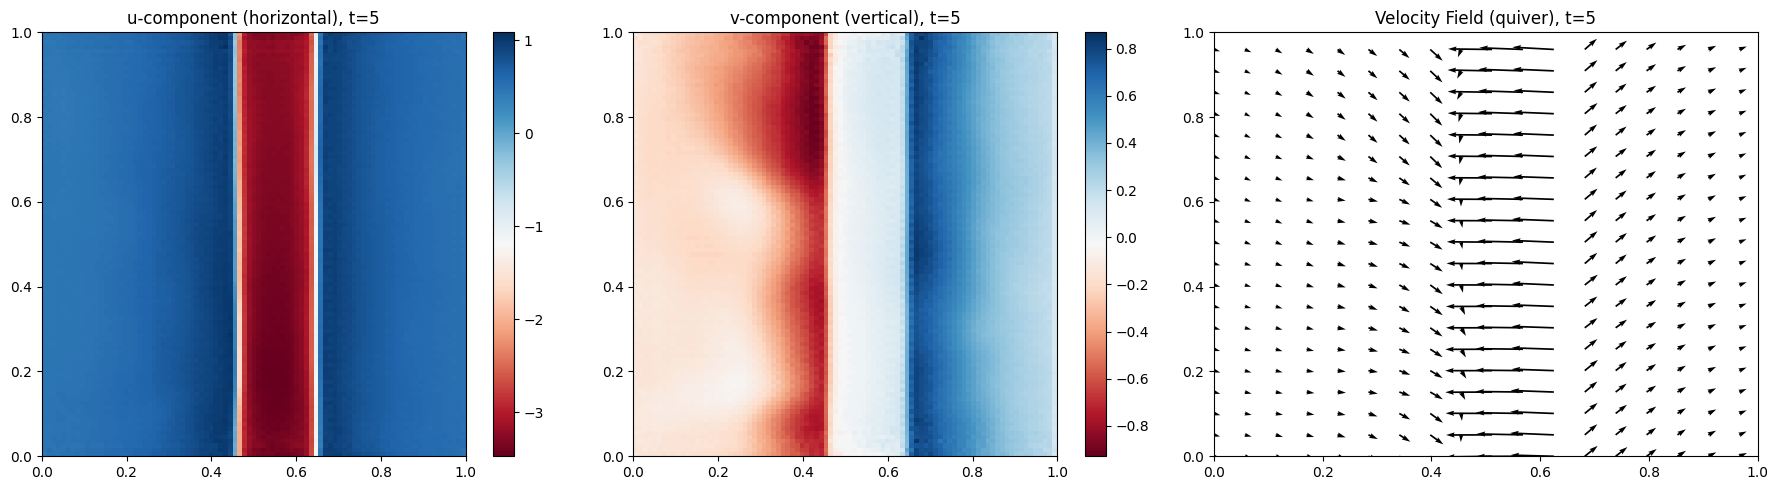

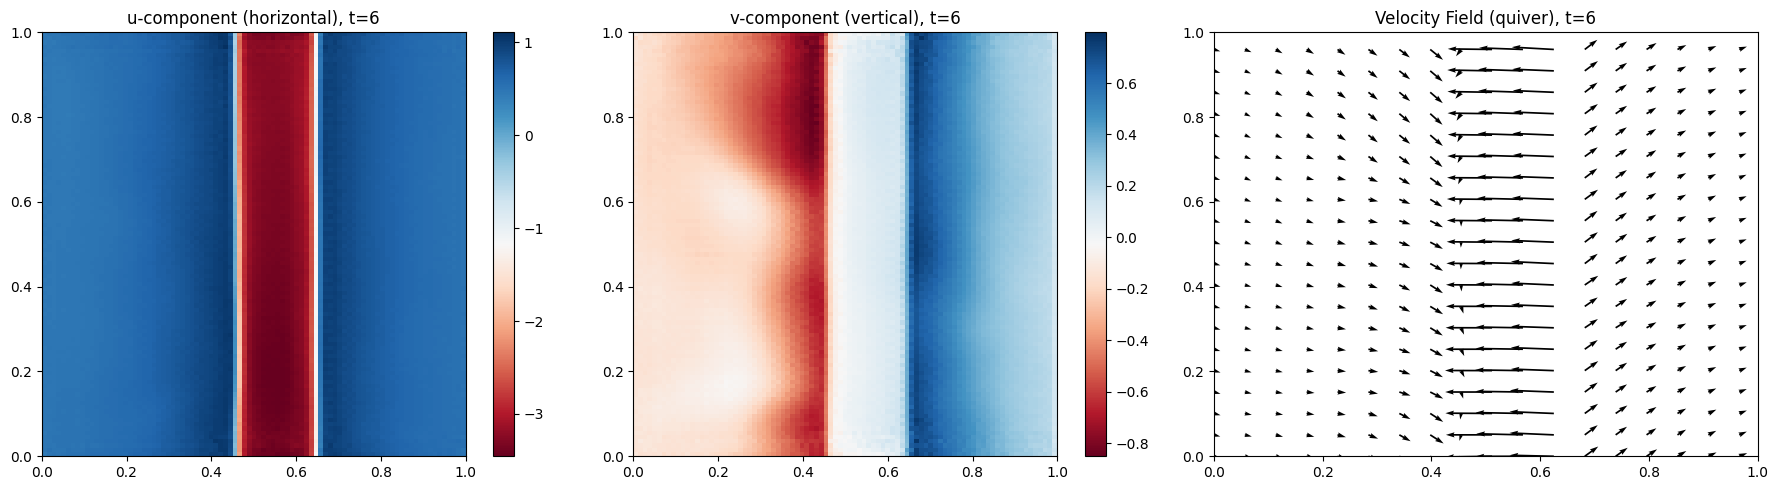

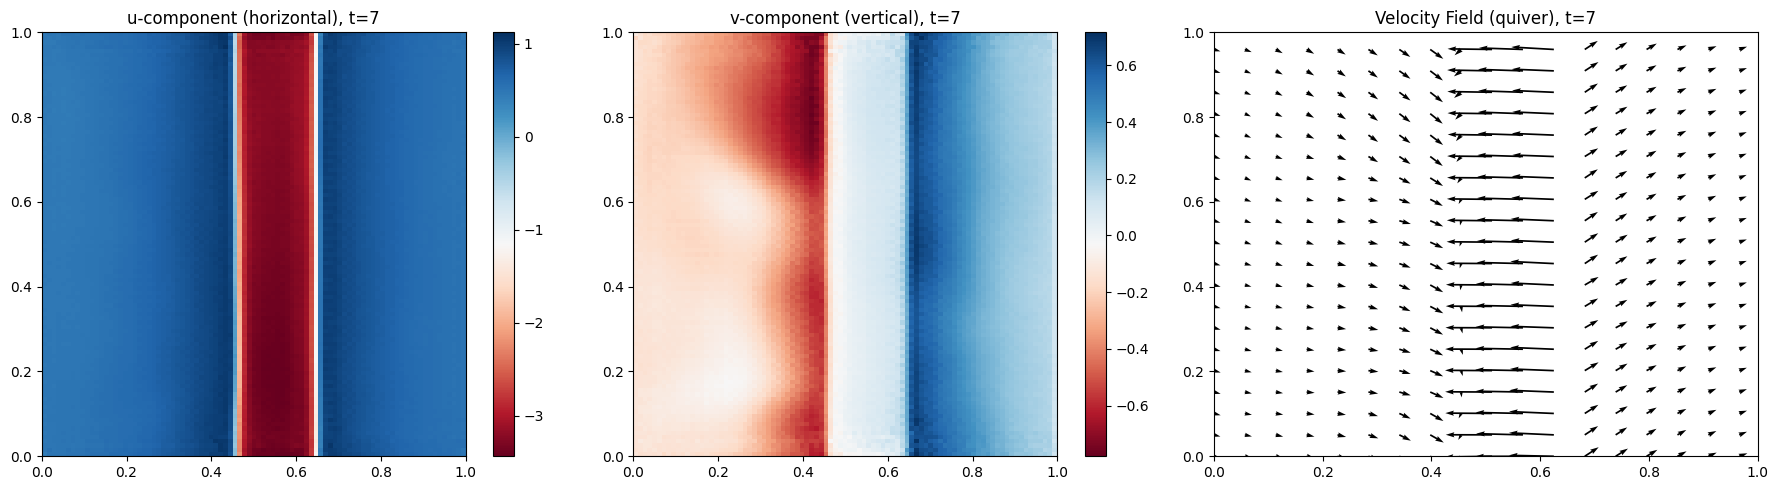

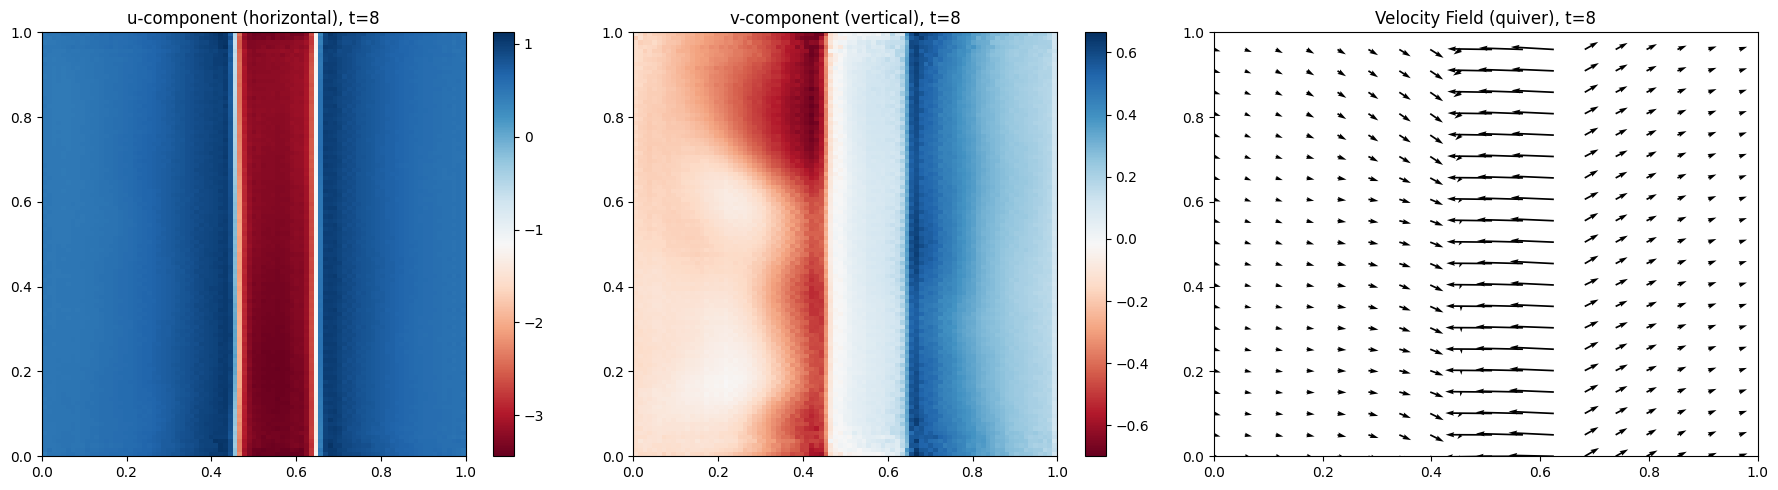

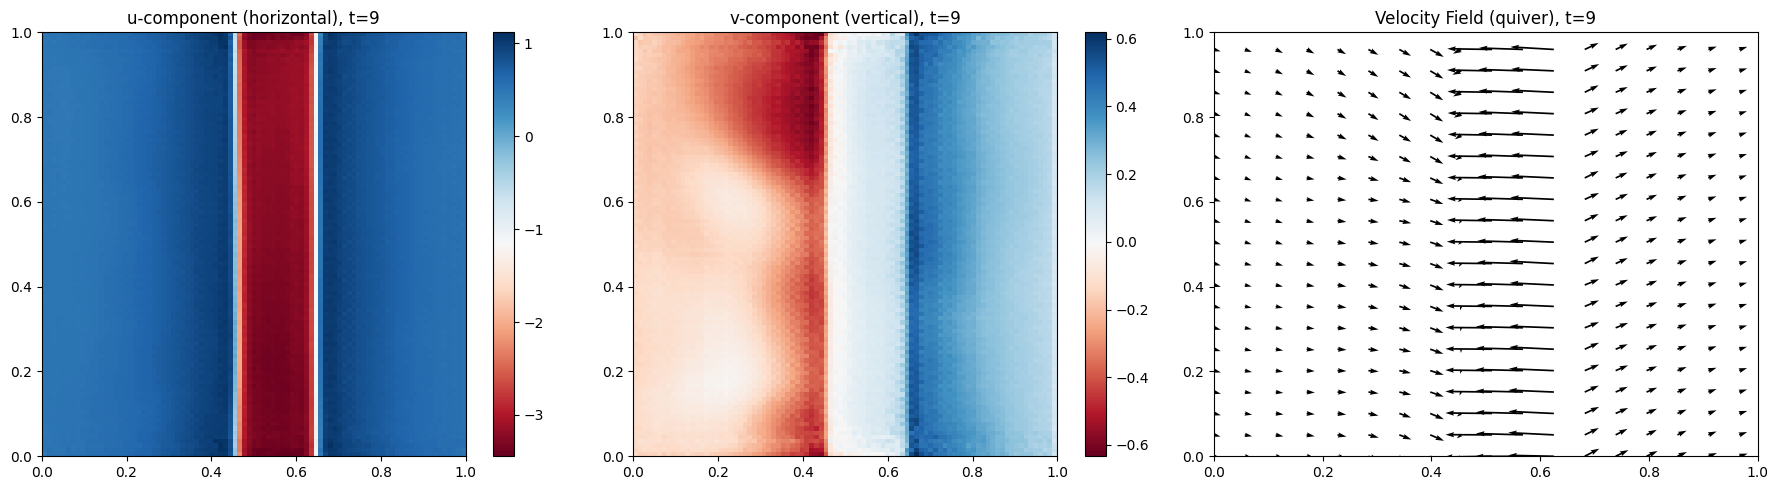

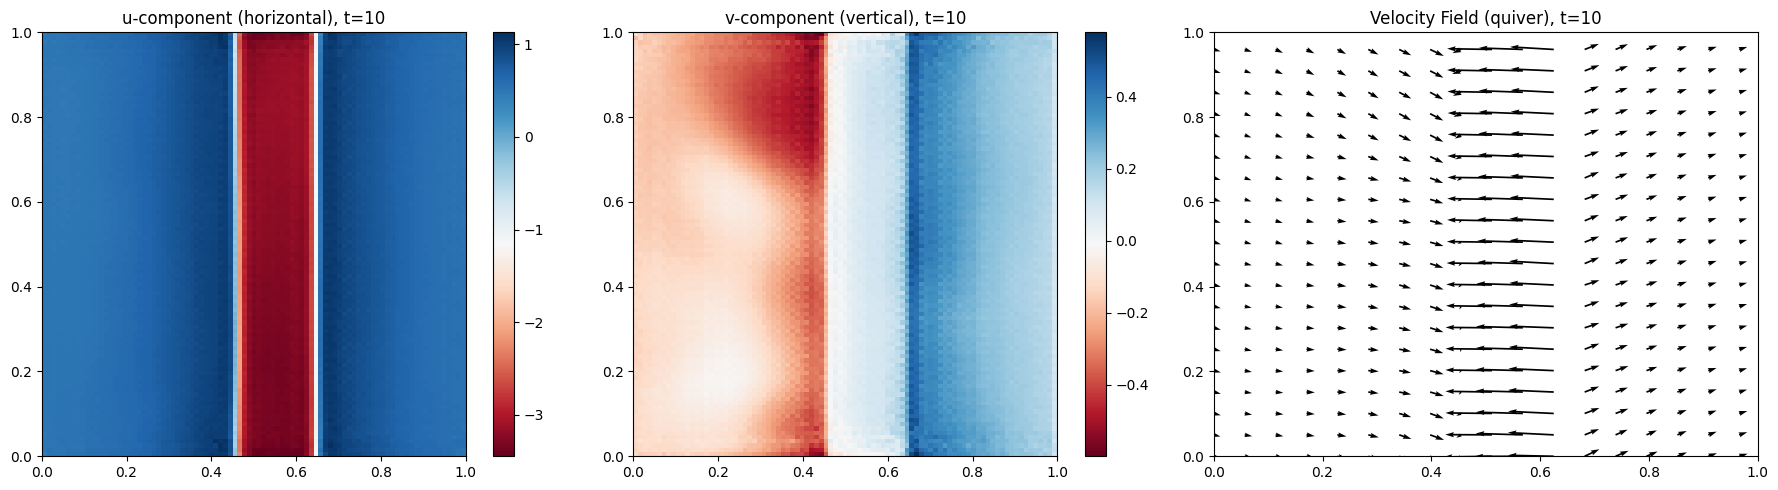

PITA outputs saved to ./UNet Output/20260619_UNet_200_epoch_32_5Hz_200fps_BASELINE_WITH_PITA.h5


In [47]:
# save PITA
p_u_actual, p_u_pred = test_recursive(model_pita, test_loader)

p_formatted_date = date.today().strftime("%Y%m%d")
p_fname = f'{output_dir}{p_formatted_date}_UNet_{epochs}_epoch_{batch_size}_{speed}_{pita_tags}.h5'

with h5py.File(p_fname, 'w') as f:
    f.create_dataset('u_actual',     data=p_u_actual.cpu().numpy())
    f.create_dataset('u_pred',       data=p_u_pred.cpu().numpy())
    f.create_dataset('train_losses', data=np.array(p_train_losses))
    f.create_dataset('test_losses',  data=np.array(p_test_losses))
    f.create_dataset('u_x_mean',     data=u_x_mean)
    f.create_dataset('u_x_std',      data=u_x_std)
    f.create_dataset('u_y_mean',     data=u_y_mean)
    f.create_dataset('u_y_std',      data=u_y_std)

print(f"PITA outputs saved to {p_fname}")
torch.save(model_pita, f'{output_dir}{p_formatted_date}_UNet_{epochs}_epoch_{batch_size}_{speed}_{pita_tags}.pt')

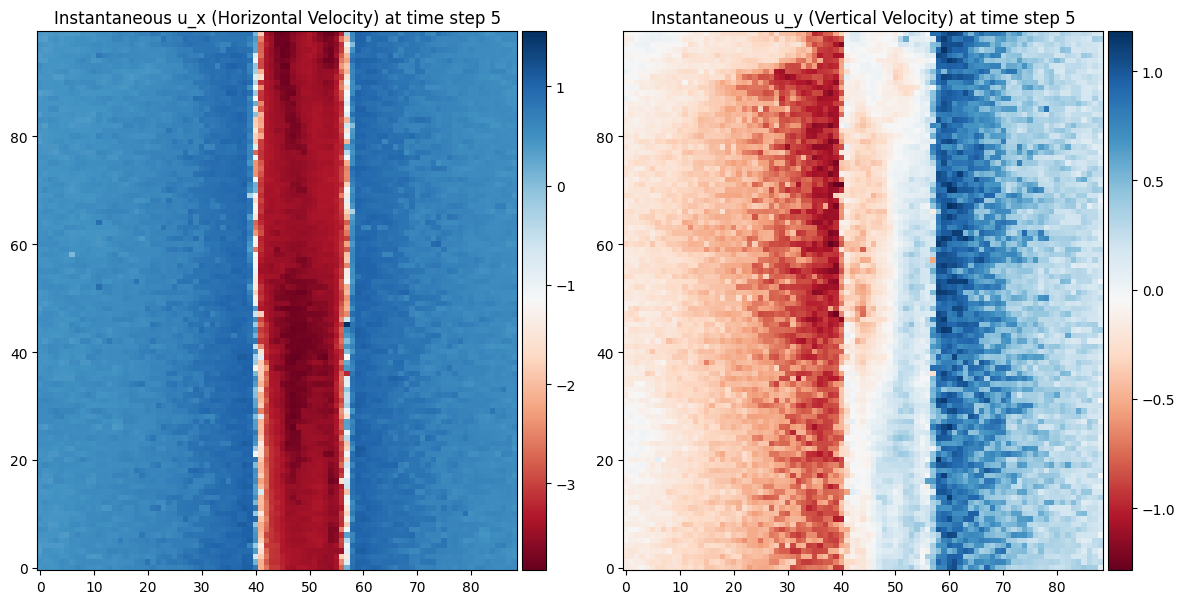

In [48]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Select a specific time step for the snapshot
time_step = 5 # You can change this to any desired time step within the data range

# Get the instantaneous velocity fields at the selected time step
u_x_snapshot = u_x[0, :, :, time_step].cpu().numpy()
u_y_snapshot = u_y[0, :, :, time_step].cpu().numpy()

# Visualize the instantaneous fields
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot u_x_snapshot
im0 = axes[0].imshow(u_x_snapshot, origin="lower", cmap="RdBu")
axes[0].set_title(f"Instantaneous u_x (Horizontal Velocity) at time step {time_step}")
divider0 = make_axes_locatable(axes[0])
cax0 = divider0.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im0, cax=cax0)

# Plot u_y_snapshot
im1 = axes[1].imshow(u_y_snapshot, origin="lower", cmap="RdBu")
axes[1].set_title(f"Instantaneous u_y (Vertical Velocity) at time step {time_step}")
divider1 = make_axes_locatable(axes[1])
cax1 = divider1.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im1, cax=cax1)

plt.tight_layout()
plt.show()

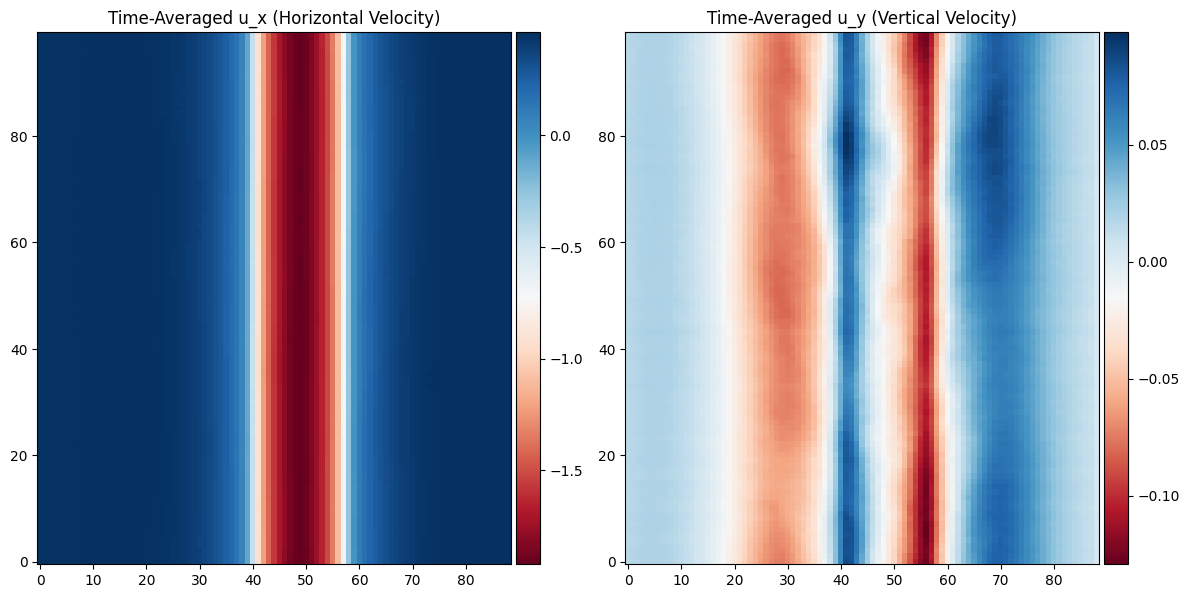

In [49]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Calculate time-averaged velocity fields
u_x_avg = torch.mean(u_x, dim=(0, -1)).cpu().numpy()
u_y_avg = torch.mean(u_y, dim=(0, -1)).cpu().numpy()

# Visualize the time-averaged fields
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot u_x_avg
im0 = axes[0].imshow(u_x_avg, origin="lower", cmap="RdBu")
axes[0].set_title("Time-Averaged u_x (Horizontal Velocity)")
divider0 = make_axes_locatable(axes[0])
cax0 = divider0.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im0, cax=cax0)

# Plot u_y_avg
im1 = axes[1].imshow(u_y_avg, origin="lower", cmap="RdBu")
axes[1].set_title("Time-Averaged u_y (Vertical Velocity)")
divider1 = make_axes_locatable(axes[1])
cax1 = divider1.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im1, cax=cax1)

plt.tight_layout()
plt.show()

In [3]:
import matplotlib.pyplot as plt
u_diff = torch.mean((u_pred - u_actual)**2, dim=(0, 1, 2, 3)).cpu().numpy()

plt.plot(u_diff, label="UNet")
plt.ylabel("Error")
plt.xlabel("Timestep")
plt.title("Error of each model at each timestep - 2Hz")
plt.legend()
plt.show()

NameError: name 'u_pred' is not defined